[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter11_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 11: Continuous-Time Models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 11: Brownian motion and Itô calculus by simulation, and GBM, Ornstein–Uhlenbeck, Merton and Heston models estimated on real data.

In [1]:
import os
import re
import io
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
LightGray = '#DADADA'
MODEL_COL = {'Data': MainBlue, 'GBM': Orange, 'Merton': Purple, 'Heston': Forest}

HERE = '.'
CHART_DIR = '.'
SEED = 42
DT = 1 / 252


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=4, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels and not ll.startswith('_'):
                    handles.append(hh)
                    labels.append(ll)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, np.ndarray):
        return [jsonable(v) for v in x.tolist()]
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500 (1990–2026), BET (2000–2026), Bitcoin (2014–2026), VIX (1990–2026).
- 3-month US Treasury bill rate (FRED series DTB3), 1954–2026.
- Equity indices: weekdays only, days with an unchanged close removed; Bitcoin: 7 days a week; daily log returns, time in years.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, tip, data de start)
MARKETS = {
    'sp500':  ('GSPC.INDX',  'S&P 500',                  'index',  '1990-01-01'),
    'bet':    ('BET',        'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC', 'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',    'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = ('bnr', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def read_fred(series, start='1954-01-01', end=END):
    """Serie zilnica FRED (Federal Reserve Bank of St. Louis), in unitatile originale."""
    key = ('fred', series, start, end)
    if key in _CACHE:
        return _CACHE[key]
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}'
    for attempt in range(4):
        try:
            raw = urllib.request.urlopen(url, timeout=120).read().decode()
            break
        except OSError:
            if attempt == 3:
                raise
    df = pd.read_csv(io.StringIO(raw), index_col=0, parse_dates=True, na_values='.')
    s = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().loc[start:end].rename(series)
    _CACHE[key] = s
    return s


def load_close(name, start=None, end=END):
    """Pretul zilnic, curatat dupa conventiile capitolului."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
    if kind == 'index':
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Frecventa reala: numarul mediu de observatii pe an calendaristic."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def load_vix(start='1990-01-01', end=END):
    """Indicele VIX (CBOE), nivelul zilnic de inchidere, in puncte de volatilitate anualizata (%)."""
    s = read_market('VIX.INDX')['close'].loc[start:end]
    s = s[(s > 0) & (s.index.dayofweek < 5)].dropna()
    return s.rename('vix')


# randamente log zilnice (nu in %), fiecare serie pe calendarul ei
rets = {k: log_returns(k) for k in ['sp500', 'bet', 'btc']}
DTS = {'sp500': 1 / 252, 'bet': 1 / 252, 'btc': 1 / 365}
for k, r in rets.items():
    print(f'{LABELS[k]:26s}', r.index[0].date(), '->', r.index[-1].date(), len(r), 'obs')

S&P 500                    1990-01-03 -> 2026-09-18 9240 obs
BET                        2000-01-06 -> 2026-09-18 6670 obs
Bitcoin                    2014-09-18 -> 2026-09-18 4384 obs


## Continuous-time models

- Brownian motion, quadratic variation, Itô and Stratonovich sums; Euler–Maruyama and Milstein.
- Geometric Brownian motion (GBM), Ornstein–Uhlenbeck (OU), Merton jump-diffusion, Lee–Mykland jump test, Heston stochastic volatility.
- Stylised facts: excess kurtosis, Hill tail index, autocorrelation of $|r_t|$.

In [4]:
# =============================================================================
# MISCAREA BROWNIANA
# =============================================================================
def scaled_random_walk(n, n_paths, rng):
    """Mersul aleator scalat W_n(t) = S_[nt] / sqrt(n), cu pasi +1/-1 egal probabili, pe grila t = k/n."""
    steps = rng.choice([-1.0, 1.0], size=(n_paths, n))
    S = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(steps, axis=1)], axis=1)
    return np.linspace(0, 1, n + 1), S / np.sqrt(n)


def bm_paths(n_paths, n_steps, T, rng):
    """Traiectorii ale miscarii browniene standard pe [0, T]: W_0 = 0, cresteri N(0, dt) independente."""
    dt = T / n_steps
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    W = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)], axis=1)
    return np.linspace(0, T, n_steps + 1), W


def quadratic_variation(W):
    """Suma patratelor cresterilor (variatia patratica pe grila data)."""
    return np.sum(np.diff(W, axis=-1) ** 2, axis=-1)


def total_variation(W):
    """Suma valorilor absolute ale cresterilor (variatia totala pe grila data)."""
    return np.sum(np.abs(np.diff(W, axis=-1)), axis=-1)


def ito_stratonovich(W):
    """Sumele Ito (capatul stang) si Stratonovich (punctul de mijloc) pentru integrala lui W dupa W."""
    dW = np.diff(W, axis=-1)
    ito = np.sum(W[..., :-1] * dW, axis=-1)
    strat = np.sum(0.5 * (W[..., :-1] + W[..., 1:]) * dW, axis=-1)
    return ito, strat


def max_prob(W, level=1.0):
    """Proportia traiectoriilor al caror maxim pe [0, T] depaseste nivelul dat."""
    return float(np.mean(W.max(axis=1) > level))


# =============================================================================
# SCHEME DE DISCRETIZARE (ecuatia de test a lui Higham: dX = lam X dt + mu X dW)
# =============================================================================
def em_milstein_gbm(x0, lam, mu, dW, dt):
    """Euler-Maruyama si Milstein pentru dX = lam X dt + mu X dW, cu cresterile browniene dW (n_paths x n)."""
    xe = np.full(dW.shape[0], x0, dtype=float)
    xm = xe.copy()
    for k in range(dW.shape[1]):
        d = dW[:, k]
        xe = xe + lam * xe * dt + mu * xe * d
        xm = xm + lam * xm * dt + mu * xm * d + 0.5 * mu ** 2 * xm * (d ** 2 - dt)
    return xe, xm


def convergence_study(rng, x0=1.0, lam=2.0, mu=1.0, T=1.0, n_fine=2 ** 11, n_paths=20000,
                      ratios=(1, 2, 4, 8, 16, 32, 64)):
    """Eroarea tare E|X_T - X^h_T| si eroarea slaba |E X^h_T - E X_T| pentru pasi dt = ratio * T / n_fine."""
    dt_f = T / n_fine
    dW = rng.standard_normal((n_paths, n_fine)) * np.sqrt(dt_f)
    WT = dW.sum(axis=1)
    x_true = x0 * np.exp((lam - 0.5 * mu ** 2) * T + mu * WT)
    ex = x0 * np.exp(lam * T)                       # E X_T exact
    rows = []
    for r in ratios:
        dWr = dW.reshape(n_paths, n_fine // r, r).sum(axis=2)
        h = r * dt_f
        xe, xm = em_milstein_gbm(x0, lam, mu, dWr, h)
        rows.append(dict(dt=h, strong_em=np.mean(np.abs(x_true - xe)), strong_mil=np.mean(np.abs(x_true - xm)),
                         strong_em_se=np.std(np.abs(x_true - xe)) / np.sqrt(n_paths),
                         strong_mil_se=np.std(np.abs(x_true - xm)) / np.sqrt(n_paths),
                         weak_em_exact=abs(x0 * (1 + lam * h) ** round(T / h) - ex),
                         weak_em_mc=abs(xe.mean() - ex), weak_mil_mc=abs(xm.mean() - ex)))
    return pd.DataFrame(rows)


def slope_ci(dt, err, level=0.95):
    """Panta regresiei log(eroare) pe log(dt), cu eroare standard si interval de incredere t."""
    x, y = np.log(np.asarray(dt)), np.log(np.asarray(err))
    res = stats.linregress(x, y)
    q = stats.t.ppf(0.5 + level / 2, len(x) - 2)
    return dict(slope=res.slope, se=res.stderr, lo=res.slope - q * res.stderr, hi=res.slope + q * res.stderr,
                intercept=res.intercept)


# =============================================================================
# MISCAREA BROWNIANA GEOMETRICA (GBM)
# =============================================================================
def gbm_paths(S0, mu, sigma, T, n_steps, n_paths, rng):
    """Solutia exacta S_t = S_0 exp((mu - sigma^2/2) t + sigma W_t) pe o grila regulata."""
    t, W = bm_paths(n_paths, n_steps, T, rng)
    return t, S0 * np.exp((mu - 0.5 * sigma ** 2) * t + sigma * W)


def gbm_mle(r, dt):
    """Verosimilitate maxima pentru GBM din randamente log r (aceeasi frecventa dt, in ani).

    r_t ~ N((mu - sigma^2/2) dt, sigma^2 dt), i.i.d.  =>  sigma^2 = var(r)/dt,  mu = mean(r)/dt + sigma^2/2.
    Erori standard: se(sigma) = sigma / sqrt(2n); se(drift log) = sigma / sqrt(n dt) (depinde doar de durata)."""
    r = np.asarray(r)
    n = len(r)
    s2 = r.var() / dt
    sigma = np.sqrt(s2)
    m = r.mean() / dt                       # drift-ul logaritmului (mu - sigma^2/2)
    return dict(n=n, years=n * dt, sigma=sigma, se_sigma=sigma / np.sqrt(2 * n), m=m, se_m=sigma / np.sqrt(n * dt),
                mu=m + 0.5 * s2)


def gbm_simulate_returns(m, sigma, n, dt, rng):
    """Randamente log i.i.d. Normale ale unei GBM (drift log m, volatilitate sigma)."""
    return m * dt + sigma * np.sqrt(dt) * rng.standard_normal(n)


# =============================================================================
# ORNSTEIN-UHLENBECK / VASICEK
# =============================================================================
def ou_exact_path(x0, kappa, theta, sigma, dt, n, rng, z=None):
    """Discretizarea exacta: x_{t+dt} = theta + (x_t - theta) e^{-kappa dt} + eps, eps ~ N(0, sigma^2 (1 - e^{-2 kappa dt}) / (2 kappa))."""
    b = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - b ** 2) / (2 * kappa))
    z = rng.standard_normal(n) if z is None else z
    x = np.empty(n + 1)
    x[0] = x0
    for k in range(n):
        x[k + 1] = theta + (x[k] - theta) * b + sd * z[k]
    return x


def ou_mle(x, dt):
    """Estimatorul de verosimilitate maxima (conditionat de x_0) al procesului OU: regresia AR(1) exacta.

    x_{t+1} = a + b x_t + e;  kappa = -ln b / dt;  theta = a / (1 - b);  sigma = s_e sqrt(2 kappa / (1 - b^2)).
    Erorile standard ale lui kappa, theta si ale timpului de injumatatire: metoda delta din covarianta OLS a (a, b)."""
    x = np.asarray(x, dtype=float)
    y, z = x[1:], x[:-1]
    X = np.column_stack([np.ones_like(z), z])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    a, b = coef
    e = y - X @ coef
    n = len(y)
    s2 = e @ e / n
    cov = s2 * np.linalg.inv(X.T @ X)
    kappa = -np.log(b) / dt
    theta = a / (1 - b)
    sigma = np.sqrt(s2 * 2 * kappa / (1 - b ** 2))
    g_k = np.array([0.0, -1 / (b * dt)])                       # d kappa / d(a, b)
    g_t = np.array([1 / (1 - b), a / (1 - b) ** 2])           # d theta / d(a, b)
    se_k = float(np.sqrt(g_k @ cov @ g_k))
    se_t = float(np.sqrt(g_t @ cov @ g_t))
    hl = np.log(2) / kappa
    return dict(n=n, a=a, b=b, kappa=kappa, se_kappa=se_k, theta=theta, se_theta=se_t, sigma=sigma,
                half_life=hl, se_half_life=hl / kappa * se_k, stat_sd=sigma / np.sqrt(2 * kappa))


def ou_bias_mc(kappa, theta, sigma, dt, n, n_sim, rng):
    """Distributia de selectie a lui kappa estimat: n_sim traiectorii OU exacte (start din distributia stationara)."""
    from scipy.signal import lfilter
    b = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - b ** 2) / (2 * kappa))
    out = np.empty(n_sim)
    for i in range(n_sim):
        e = sd * rng.standard_normal(n)
        e[0] = sigma / np.sqrt(2 * kappa) * rng.standard_normal()
        x = theta + lfilter([1.0], [1.0, -b], e)
        out[i] = ou_mle(x, dt)['kappa']
    return out


# =============================================================================
# DIFUZII NELINIARE: VEROSIMILITATE EXACTA (CIR) VS EULER; CKLS; ESTIMARE NEPARAMETRICA
# =============================================================================
def vasicek_loglik(x, dt, kappa, theta, sigma, per_obs=False):
    """Log-verosimilitatea exacta Vasicek (tranzitie Normala, AR(1) exact)."""
    r0, r1 = x[:-1], x[1:]
    b = np.exp(-kappa * dt)
    ll = stats.norm.logpdf(r1, theta + (r0 - theta) * b, sigma * np.sqrt((1 - b * b) / (2 * kappa)))
    return ll if per_obs else ll.sum()


def cir_loglik(x, dt, kappa, theta, sigma, per_obs=False):
    """Log-verosimilitatea exacta CIR: 2c r_{t+dt} | r_t ~ chi-patrat necentral cu 4 kappa theta / sigma^2 grade de libertate
    si parametrul de noncentralitate 2c r_t e^{-kappa dt}, c = 2 kappa / (sigma^2 (1 - e^{-kappa dt})) (Cox, Ingersoll, Ross 1985)."""
    r0, r1 = x[:-1], x[1:]
    c = 2 * kappa / (sigma ** 2 * (1 - np.exp(-kappa * dt)))
    ll = np.log(2 * c) + stats.ncx2.logpdf(2 * c * r1, 4 * kappa * theta / sigma ** 2, 2 * c * r0 * np.exp(-kappa * dt))
    return ll if per_obs else ll.sum()


def euler_loglik(x, dt, kappa, theta, sigma, gamma, per_obs=False):
    """Pseudo-verosimilitatea Euler (Gaussiana) pentru dr = kappa (theta - r) dt + sigma r^gamma dW
    (gamma = 0: Vasicek, gamma = 1/2: CIR, gamma liber: Chan, Karolyi, Longstaff, Sanders 1992)."""
    r0, r1 = x[:-1], x[1:]
    ll = stats.norm.logpdf(r1, r0 + kappa * (theta - r0) * dt, sigma * r0 ** gamma * np.sqrt(dt))
    return ll if per_obs else ll.sum()


def _fit(nll, p0):
    best = None
    for scale in (1.0, 0.5, 2.0):
        q0 = np.array(p0, dtype=float)
        q0[0] *= scale
        res = optimize.minimize(nll, q0, method='Nelder-Mead', options=dict(maxiter=40000, maxfev=40000, xatol=1e-10, fatol=1e-8))
        res = optimize.minimize(nll, res.x, method='Nelder-Mead', options=dict(maxiter=40000, maxfev=40000, xatol=1e-10, fatol=1e-8))
        if best is None or res.fun < best.fun:
            best = res
    return best


def short_rate_fits(x, dt):
    """Vasicek (exact si Euler), CIR (exact si Euler) si CKLS (Euler) pe aceeasi serie; erori standard din hessiana
    (pentru CKLS si erori robuste sandwich, deoarece verosimilitatea Gaussiana Euler este doar o cvasi-verosimilitate)."""
    x = np.asarray(x, dtype=float)
    specs = {
        'vasicek_exact': (lambda p: vasicek_loglik(x, dt, p[0], p[1], p[2]), lambda q: (q[0], q[1], np.exp(q[2])), 0.0),
        'vasicek_euler': (lambda p: euler_loglik(x, dt, p[0], p[1], p[2], 0.0), lambda q: (q[0], q[1], np.exp(q[2])), 0.0),
        'cir_euler': (lambda p: euler_loglik(x, dt, p[0], p[1], p[2], 0.5), lambda q: (q[0], q[1], np.exp(q[2])), 0.5),
        'cir_exact': (lambda p: cir_loglik(x, dt, p[0], p[1], p[2]), lambda q: (q[0], q[1], np.exp(q[2])), 0.5),
    }
    out = {}
    m = x.mean()
    for name, (ll, unpack, g) in specs.items():
        s0 = 0.015 if g == 0 else 0.015 / np.sqrt(m)

        def nll(q, ll=ll, unpack=unpack):
            k, th, sg = unpack(q)
            if k <= 0 or th <= 0:
                return 1e18
            v = -ll((k, th, sg))
            return v if np.isfinite(v) else 1e18
        res = _fit(nll, [0.2, m, np.log(s0)])
        th = np.array(unpack(res.x))
        H = numerical_hessian(lambda t, ll=ll: -ll(t), th)
        se = np.sqrt(np.maximum(np.diag(np.linalg.inv(H)), 0))
        out[name] = dict(kappa=th[0], theta=th[1], sigma=th[2], gamma=g, se_kappa=se[0], se_theta=se[1], se_sigma=se[2],
                         loglik=-res.fun)
    # CKLS: gamma liber
    best = None
    for g0 in (0.5, 1.0, 1.5):
        def nll(q):
            if q[0] <= 0 or q[1] <= 0:
                return 1e18
            v = -euler_loglik(x, dt, q[0], q[1], np.exp(q[2]), q[3])
            return v if np.isfinite(v) else 1e18
        res = _fit(nll, [0.2, m, np.log(0.015 * m ** (-g0)), g0])
        if best is None or res.fun < best.fun:
            best = res
    th = np.array([best.x[0], best.x[1], np.exp(best.x[2]), best.x[3]])
    f = lambda t: euler_loglik(x, dt, *t)
    H = -numerical_hessian(f, th)
    Hi = np.linalg.inv(H)
    h = 1e-5 * np.maximum(np.abs(th), 1e-2)
    sc = np.column_stack([(euler_loglik(x, dt, *(th + e), per_obs=True) - euler_loglik(x, dt, *(th - e), per_obs=True)) / (2 * hi)
                          for e, hi in zip(np.diag(h), h)])
    V = Hi @ (sc.T @ sc) @ Hi
    out['ckls'] = dict(kappa=th[0], theta=th[1], sigma=th[2], gamma=th[3], se_gamma=float(np.sqrt(Hi[3, 3])),
                       se_gamma_rob=float(np.sqrt(V[3, 3])), se_kappa=float(np.sqrt(Hi[0, 0])), loglik=-best.fun)
    c = out['ckls']
    c['lr_g0'] = 2 * (c['loglik'] - out['vasicek_euler']['loglik'])
    c['lr_g05'] = 2 * (c['loglik'] - out['cir_euler']['loglik'])
    c['wald_g0'] = (c['gamma'] / c['se_gamma_rob']) ** 2
    c['wald_g05'] = ((c['gamma'] - 0.5) / c['se_gamma_rob']) ** 2
    out['n'] = len(x) - 1
    return out


def nw_drift_diffusion(x, dt, grid, h=None):
    """Estimatori Nadaraya-Watson (nucleu Gaussian) pentru driftul a(r) = E[dr | r] / dt si difuzia
    b^2(r) = E[(dr)^2 | r] / dt (Stanton 1997; Bandi si Phillips 2003); erori standard punctuale robuste la heteroscedasticitate
    (dependenta seriala a erorilor este ignorata)."""
    x = np.asarray(x, dtype=float)
    r0, d = x[:-1], np.diff(x)
    if h is None:
        h = 1.06 * r0.std() * len(r0) ** (-0.2)
    out = {'grid': np.asarray(grid), 'h': h}
    for name, y in [('drift', d / dt), ('diff2', d ** 2 / dt)]:
        m, se = [], []
        for g in grid:
            w = np.exp(-0.5 * ((r0 - g) / h) ** 2)
            w /= w.sum()
            mm = w @ y
            m.append(mm)
            se.append(np.sqrt((w ** 2) @ (y - mm) ** 2))
        out[name], out[name + '_se'] = np.array(m), np.array(se)
    return out


# =============================================================================
# MERTON: DIFUZIE CU SALTURI
# =============================================================================
def merton_logpdf(r, dt, m, sigma, lam, mu_j, s_j, kmax=12):
    """Log-densitatea randamentelor log pe un pas dt:  r = m dt + sigma W_dt + suma a N salturi N(mu_j, s_j^2),
    N ~ Poisson(lam dt). Densitatea este o mixtura de distributii Normale ponderate cu probabilitatile Poisson."""
    r = np.asarray(r)[:, None]
    k = np.arange(kmax + 1)[None, :]
    w = stats.poisson.pmf(k, lam * dt)
    mean = m * dt + k * mu_j
    var = sigma ** 2 * dt + k * s_j ** 2
    dens = (w * np.exp(-0.5 * (r - mean) ** 2 / var) / np.sqrt(2 * np.pi * var)).sum(axis=1)
    return np.log(np.maximum(dens, 1e-300))


def _merton_unpack(p):
    return p[0], np.exp(p[1]), np.exp(p[2]), p[3], np.exp(p[4])


def merton_mle(r, dt, starts=None):
    """Verosimilitate maxima pentru Merton (m, sigma, lam, mu_j, s_j); mai multe puncte de start.
    Erorile standard: inversa hessianei numerice in parametrii originali (metoda delta)."""
    r = np.asarray(r)
    sd = r.std()
    nll = lambda p: -merton_logpdf(r, dt, *_merton_unpack(p)).sum()
    if starts is None:
        starts = []
        for lam0 in (2.0, 10.0, 40.0):
            for sj0 in (1.5, 3.0):
                starts.append([r.mean() / dt, np.log(0.7 * sd / np.sqrt(dt)), np.log(lam0), -0.5 * sd, np.log(sj0 * sd)])
    best = None
    for s0 in starts:
        res = optimize.minimize(nll, s0, method='Nelder-Mead', options=dict(maxiter=20000, maxfev=20000, xatol=1e-7, fatol=1e-7))
        res = optimize.minimize(nll, res.x, method='BFGS')
        if best is None or res.fun < best.fun:
            best = res
    m, sigma, lam, mu_j, s_j = _merton_unpack(best.x)
    theta = np.array([m, sigma, lam, mu_j, s_j])
    nll_orig = lambda th: -merton_logpdf(r, dt, *th).sum()
    H = numerical_hessian(nll_orig, theta)
    try:
        cov = np.linalg.inv(H)
        se = np.sqrt(np.maximum(np.diag(cov), 0))
    except np.linalg.LinAlgError:
        se = np.full(5, np.nan)
    return dict(m=m, sigma=sigma, lam=lam, mu_j=mu_j, s_j=s_j, se=dict(zip(['m', 'sigma', 'lam', 'mu_j', 's_j'], se)),
                loglik=-best.fun, n=len(r))


def numerical_hessian(f, x, rel=1e-4):
    """Hessiana prin diferente finite centrale."""
    x = np.asarray(x, dtype=float)
    k = len(x)
    h = rel * np.maximum(np.abs(x), 1e-3)
    H = np.empty((k, k))
    for i in range(k):
        for j in range(i, k):
            ei, ej = np.zeros(k), np.zeros(k)
            ei[i], ej[j] = h[i], h[j]
            H[i, j] = H[j, i] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h[i] * h[j])
    return H


def merton_moments(dt, sigma, lam, mu_j, s_j, m=0.0):
    """Media, dispersia, asimetria si excesul de aplatizare ale randamentului Merton pe un pas dt (cumulanti)."""
    k1 = m * dt + lam * dt * mu_j
    k2 = sigma ** 2 * dt + lam * dt * (mu_j ** 2 + s_j ** 2)
    k3 = lam * dt * (mu_j ** 3 + 3 * mu_j * s_j ** 2)
    k4 = lam * dt * (mu_j ** 4 + 6 * mu_j ** 2 * s_j ** 2 + 3 * s_j ** 4)
    return dict(mean=k1, var=k2, skew=k3 / k2 ** 1.5, exkurt=k4 / k2 ** 2)


def merton_simulate_returns(m, sigma, lam, mu_j, s_j, n, dt, rng):
    """Randamente log simulate din modelul Merton."""
    N = rng.poisson(lam * dt, n)
    jumps = mu_j * N + s_j * np.sqrt(N) * rng.standard_normal(n)
    return m * dt + sigma * np.sqrt(dt) * rng.standard_normal(n) + jumps


def lr_bootstrap(r, dt, n_boot, rng):
    """Testul raportului de verosimilitate GBM (fara salturi) vs Merton, cu valoarea p din bootstrap parametric.
    Sub ipoteza nula lam = 0 se afla pe frontiera, iar mu_j, s_j nu sunt identificati: distributia chi-patrat nu se aplica."""
    r = np.asarray(r)
    g = gbm_mle(r, dt)
    ll0 = stats.norm.logpdf(r, r.mean(), r.std()).sum()
    mf = merton_mle(r, dt)
    lr = 2 * (mf['loglik'] - ll0)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        rb = gbm_simulate_returns(g['m'], g['sigma'], len(r), dt, rng)
        l0 = stats.norm.logpdf(rb, rb.mean(), rb.std()).sum()
        mb = merton_mle(rb, dt, starts=[[rb.mean() / dt, np.log(rb.std() / np.sqrt(dt)), np.log(5.0), 0.0, np.log(2 * rb.std())],
                                        [rb.mean() / dt, np.log(0.8 * rb.std() / np.sqrt(dt)), np.log(30.0), 0.0, np.log(1.5 * rb.std())]])
        boot[i] = max(2 * (mb['loglik'] - l0), 0.0)
    return dict(lr=lr, p_boot=float(np.mean(boot >= lr)), boot=boot, crit95=float(np.quantile(boot, 0.95)), merton=mf)


# =============================================================================
# TESTUL DE SALTURI LEE-MYKLAND
# =============================================================================
def lee_mykland(r, K=16, alpha=0.01):
    """Statistica L_t = r_t / sigma_t, cu sigma_t^2 = variatia bipower pe cele K-1 randamente anterioare;
    salt detectat daca (|L_t| - C_n) / S_n depaseste cuantila 1 - alpha a distributiei Gumbel (Lee & Mykland, 2008)."""
    r = pd.Series(r).dropna()
    a = r.abs()
    bpv = (a * a.shift(1)).rolling(K - 2).sum().shift(1) / (K - 2)
    L = (r / np.sqrt(bpv)).dropna()
    n = len(L)
    c = np.sqrt(2 / np.pi)
    ln = np.log(n)
    Cn = np.sqrt(2 * ln) / c - (np.log(np.pi) + np.log(ln)) / (2 * c * np.sqrt(2 * ln))
    Sn = 1 / (c * np.sqrt(2 * ln))
    crit = -np.log(-np.log(1 - alpha))
    stat = (L.abs() - Cn) / Sn
    return pd.DataFrame({'r': r.reindex(L.index), 'L': L, 'stat': stat, 'jump': stat > crit}), crit


# =============================================================================
# HESTON: VOLATILITATE STOCHASTICA
# =============================================================================
def heston_paths(S0, v0, mu, kappa, theta, xi, rho, T, n_steps, n_paths, rng, antithetic=False):
    """Schema Euler cu trunchiere completa (Lord et al., 2010) pentru log S si v.
    d ln S = (mu - v/2) dt + sqrt(v) dW1;  dv = kappa (theta - v) dt + xi sqrt(v) dW2;  corr(dW1, dW2) = rho."""
    dt = T / n_steps
    m = n_paths // 2 if antithetic else n_paths
    x = np.full(n_paths, np.log(S0))
    v = np.full(n_paths, v0, dtype=float)
    X = np.empty((n_steps + 1, n_paths))
    V = np.empty((n_steps + 1, n_paths))
    X[0], V[0] = x, v
    for k in range(n_steps):
        z1 = rng.standard_normal(m)
        z2 = rng.standard_normal(m)
        if antithetic:
            z1, z2 = np.concatenate([z1, -z1]), np.concatenate([z2, -z2])
        w2 = rho * z1 + np.sqrt(1 - rho ** 2) * z2
        vp = np.maximum(v, 0.0)
        x = x + (mu - 0.5 * vp) * dt + np.sqrt(vp * dt) * z1
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * w2
        X[k + 1], V[k + 1] = x, np.maximum(v, 0.0)
    return np.linspace(0, T, n_steps + 1), np.exp(X), V


def heston_from_vix(vix, logret, dt):
    """Parametrii Heston din VIX: v_t = (VIX_t / 100)^2 ca aproximare a variantei; regresia CIR discretizata
    (v_{t+1} - v_t) / sqrt(v_t) = kappa theta dt / sqrt(v_t) - kappa dt sqrt(v_t) + xi sqrt(dt) eps;
    rho = corelatia dintre socurile de randament si socurile de varianta."""
    d = pd.concat([vix.rename('vix'), logret.rename('r')], axis=1, join='inner').dropna()
    v = (d['vix'] / 100) ** 2
    y = (v.shift(-1) - v) / np.sqrt(v)
    X = np.column_stack([dt / np.sqrt(v), -dt * np.sqrt(v)])
    ok = y.notna().values
    beta, *_ = np.linalg.lstsq(X[ok], y.values[ok], rcond=None)
    kappa = beta[1]
    theta = beta[0] / kappa
    res = y.values[ok] - X[ok] @ beta
    xi = res.std() / np.sqrt(dt)
    dv = (v.shift(-1) - v - kappa * (theta - v) * dt) / np.sqrt(v)
    zr = (d['r'].shift(-1) - d['r'].mean()) / np.sqrt(v)
    rho = pd.concat([dv, zr], axis=1).dropna().corr().iloc[0, 1]
    return dict(kappa=kappa, theta=theta, xi=xi, rho=rho, v0=float(v.iloc[-1]), n=int(ok.sum()),
                feller=2 * kappa * theta / xi ** 2, mean_vix=float(d['vix'].mean()),
                real_var=float(d['r'].var() / dt))


def heston_from_proxy(logret, dt, window=21):
    """Aceeasi regresie CIR, cu varianta aproximata prin varianta realizata anualizata pe o fereastra mobila
    (pentru piete fara un indice de volatilitate, de exemplu BET si Bitcoin)."""
    rv = (logret ** 2).rolling(window).mean() / dt
    proxy = 100 * np.sqrt(rv)
    return heston_from_vix(proxy.dropna(), logret, dt)


def heston_simulate_returns(p, n, dt, rng, mu=0.0, burn=500):
    """Randamente log zilnice simulate din Heston (cu o perioada de incalzire de burn pasi)."""
    T = (n + burn) * dt
    _, S, _ = heston_paths(1.0, p['theta'], mu, p['kappa'], p['theta'], p['xi'], p['rho'], T, n + burn, 1, rng)
    return np.diff(np.log(S[:, 0]))[burn:]


def bs_call(S, K, T, sigma, r=0.0):
    """Pretul Black-Scholes al unei optiuni call europene."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d1 - sigma * np.sqrt(T))


def implied_vol(price, S, K, T, r=0.0):
    """Volatilitatea implicita Black-Scholes (radacina prin metoda Brent)."""
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if price <= intrinsic + 1e-10:
        return np.nan
    return optimize.brentq(lambda s: bs_call(S, K, T, s, r) - price, 1e-4, 5.0)


def heston_smile(p, T, strikes, rng, n_paths=100000, n_steps=126):
    """Preturi Monte Carlo ale optiunilor call sub Heston (rata zero, mu = 0) si volatilitatile implicite."""
    _, S, _ = heston_paths(1.0, p['v0'], 0.0, p['kappa'], p['theta'], p['xi'], p['rho'], T, n_steps, n_paths, rng,
                           antithetic=True)
    ST = S[-1] / S[-1].mean()                 # corectie de martingal: E[S_T] = S_0 = 1
    return np.array([implied_vol(np.maximum(ST - K, 0).mean(), 1.0, K, T) for K in strikes])


# =============================================================================
# FAPTE STILIZATE
# =============================================================================
def acf(x, lags):
    x = np.asarray(x) - np.mean(x)
    d = x @ x
    return np.array([x[k:] @ x[:-k] / d for k in lags])


def hill(x, share=0.05):
    """Estimatorul Hill al indicelui de coada pentru cele mai mari share din valori (pierderi)."""
    x = np.sort(np.asarray(x))[::-1]
    k = int(share * len(x))
    return 1 / np.mean(np.log(x[:k] / x[k]))


def stylised(r, lags=range(1, 51)):
    """Faptele stilizate folosite pentru compararea modelelor cu datele."""
    r = np.asarray(r)
    a = acf(np.abs(r), list(lags))
    return dict(exkurt=float(stats.kurtosis(r)), skew=float(stats.skew(r)), hill=float(hill(-r)),
                acf_abs1=float(a[0]), acf_abs_sum20=float(a[:20].sum()), acf_r1=float(acf(r, [1])[0]),
                acf_abs=a)

## 1. From random walk to Brownian motion

- Scaled random walks and the probability that the path maximum exceeds 1 (reflection principle).

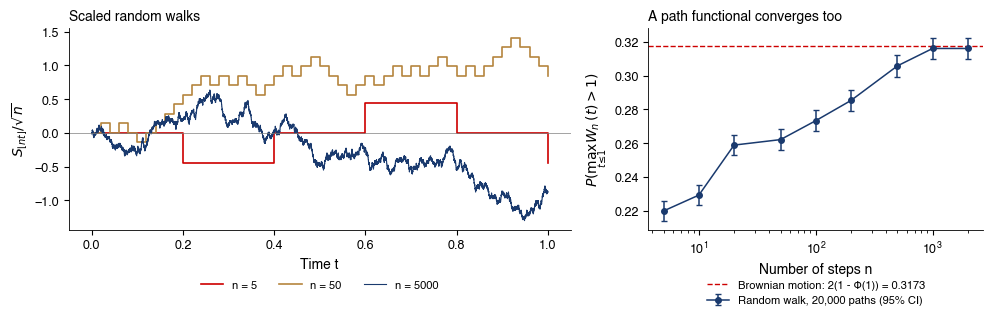

{'n': [5, 10, 20, 50, 100, 200, 500, 1000, 2000],
 'p': [0.2199,
  0.22925,
  0.25885,
  0.2621,
  0.2733,
  0.28525,
  0.30575,
  0.31605,
  0.31605],
 'se': [np.float64(0.0029286856266933126),
  np.float64(0.0029723260041590325),
  np.float64(0.003097149314288867),
  np.float64(0.0031096912226135894),
  np.float64(0.0031512466580704214),
  np.float64(0.003192823495747925),
  np.float64(0.003257813204436375),
  np.float64(0.003287570512551784),
  np.float64(0.003287570512551784)],
 'exact': np.float64(0.31731050786291415)}

In [5]:
def fig_donsker():
    """Mersul aleator scalat pentru n = 5, 50, 5000 si probabilitatea P(max W > 1) (principiul reflexiei)."""
    rng = np.random.default_rng(SEED)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={'width_ratios': [1.5, 1]})
    for n, c in zip([5, 50, 5000], [IDAred, Amber, MainBlue]):
        t, W = scaled_random_walk(n, 1, rng)
        axes[0].step(t, W[0], where='post', color=c, lw=1.2 if n < 5000 else 0.8, label=f'n = {n}')
    axes[0].axhline(0, color=Gray, lw=0.5)
    axes[0].set_xlabel('Time t')
    axes[0].set_ylabel(r'$S_{\lfloor nt \rfloor}/\sqrt{n}$')
    axes[0].set_title('Scaled random walks', loc='left')
    ns = [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
    M = 20000
    out = {'n': ns, 'p': [], 'se': []}
    for n in ns:
        _, W = scaled_random_walk(n, M, rng)
        p = max_prob(W, 1.0)
        out['p'].append(p)
        out['se'].append(np.sqrt(p * (1 - p) / M))
    exact = 2 * (1 - stats.norm.cdf(1.0))
    axes[1].errorbar(ns, out['p'], yerr=1.96 * np.array(out['se']), fmt='o-', color=MainBlue, ms=4, capsize=2,
                     label='Random walk, 20,000 paths (95% CI)')
    axes[1].axhline(exact, color=IDAred, ls='--', lw=1, label=f'Brownian motion: 2(1 - Φ(1)) = {exact:.4f}')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Number of steps n')
    axes[1].set_ylabel(r'$P(\max_{t \leq 1} W_n(t) > 1)$')
    axes[1].set_title('A path functional converges too', loc='left')
    legend_outside_bottom(axes[0], ncol=3, y=-0.2)
    legend_outside_bottom(axes[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_donsker')
    out['exact'] = exact
    return out


fig_donsker()

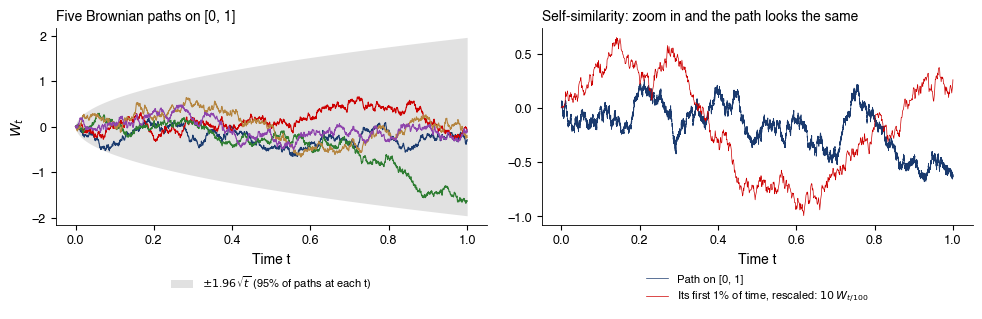

In [6]:
def fig_bm_paths():
    """Traiectorii browniene cu banda +-1.96 sqrt(t) si autosimilaritatea (zoom de 100x in timp, 10x in spatiu)."""
    rng = np.random.default_rng(SEED + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    t, W = bm_paths(5, 2000, 1.0, rng)
    axes[0].fill_between(t, -1.96 * np.sqrt(t), 1.96 * np.sqrt(t), color=LightGray, alpha=0.8, lw=0,
                         label=r'$\pm 1.96\sqrt{t}$ (95% of paths at each t)')
    for w, c in zip(W, [MainBlue, IDAred, Forest, Amber, Purple]):
        axes[0].plot(t, w, color=c, lw=0.8)
    axes[0].set_xlabel('Time t')
    axes[0].set_ylabel(r'$W_t$')
    axes[0].set_title('Five Brownian paths on [0, 1]', loc='left')
    t2, W2 = bm_paths(1, 100000, 1.0, rng)
    w = W2[0]
    axes[1].plot(t2, w, color=MainBlue, lw=0.5, label='Path on [0, 1]')
    k = 1000                                             # [0, 0.01] rescalat: timp x100, spatiu x10
    axes[1].plot(t2[:k + 1] * 100, w[:k + 1] * 10, color=IDAred, lw=0.5,
                 label=r'Its first 1% of time, rescaled: $10\,W_{t/100}$')
    axes[1].set_xlabel('Time t')
    axes[1].set_title('Self-similarity: zoom in and the path looks the same', loc='left')
    legend_outside_bottom(axes[0], ncol=1, y=-0.2)
    legend_outside_bottom(axes[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_bm_paths')


fig_bm_paths()

## 2. Quadratic variation and Itô's formula

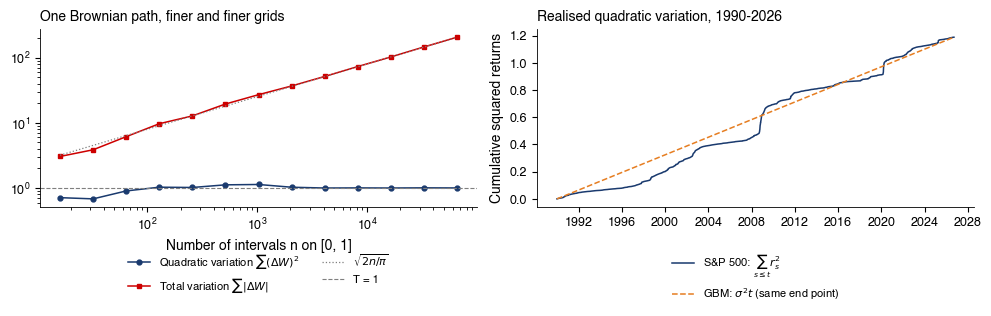

{'qv': {'16': np.float64(0.7138681317338418),
  '32': np.float64(0.6840191825340014),
  '64': np.float64(0.9045659588572135),
  '128': np.float64(1.032672681859851),
  '256': np.float64(1.021981358881963),
  '512': np.float64(1.1222060141137589),
  '1024': np.float64(1.1360916284084546),
  '2048': np.float64(1.0313010619799075),
  '4096': np.float64(1.0032445101615681),
  '8192': np.float64(1.0072360789067363),
  '16384': np.float64(1.003434552898292),
  '32768': np.float64(1.0094473310572316),
  '65536': np.float64(1.0057201566972833)},
 'tv': {'16': np.float64(3.053861630404051),
  '32': np.float64(3.8645990610339),
  '64': np.float64(6.137303821238644),
  '128': np.float64(9.689649848377304),
  '256': np.float64(12.760515890285895),
  '512': np.float64(19.417620612374826),
  '1024': np.float64(26.99110370685425),
  '2048': np.float64(36.708123295102666),
  '4096': np.float64(51.374465346217065),
  '8192': np.float64(72.79503921839044),
  '16384': np.float64(102.24661317102549),
  '3

In [7]:
def fig_quadratic_variation():
    """Variatia patratica si totala pe grile tot mai fine; variatia patratica realizata a S&P 500."""
    rng = np.random.default_rng(SEED + 2)
    N = 2 ** 16
    _, W = bm_paths(1, N, 1.0, rng)
    w = W[0]
    ns = [2 ** k for k in range(4, 17)]
    qv = [quadratic_variation(w[::N // n]) for n in ns]
    tv = [total_variation(w[::N // n]) for n in ns]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    axes[0].plot(ns, qv, 'o-', color=MainBlue, ms=3.5, label=r'Quadratic variation $\sum (\Delta W)^2$')
    axes[0].plot(ns, tv, 's-', color=IDAred, ms=3.5, label=r'Total variation $\sum |\Delta W|$')
    axes[0].plot(ns, np.sqrt(2 * np.array(ns) / np.pi), color=Gray, ls=':', lw=0.9, label=r'$\sqrt{2n/\pi}$')
    axes[0].axhline(1.0, color=Gray, ls='--', lw=0.8, label='T = 1')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Number of intervals n on [0, 1]')
    axes[0].set_title('One Brownian path, finer and finer grids', loc='left')
    r = rets['sp500']
    cum = (r ** 2).cumsum()
    years = (r.index - r.index[0]).days / 365.25
    lin = cum.iloc[-1] * years / years[-1]
    axes[1].plot(r.index, cum, color=MainBlue, lw=1.1, label=r'S&P 500: $\sum_{s \leq t} r_s^2$')
    axes[1].plot(r.index, lin, color=Orange, ls='--', lw=1.1, label=r'GBM: $\sigma^2 t$ (same end point)')
    axes[1].set_ylabel('Cumulative squared returns')
    axes[1].set_title('Realised quadratic variation, 1990-2026', loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.2)
    legend_outside_bottom(axes[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_quadratic_variation')
    gaps = {}
    for a, b in [('2008-09-01', '2009-03-31'), ('2020-02-20', '2020-04-30')]:
        seg = r.loc[a:b]
        gaps[a[:4]] = dict(share_qv=float((seg ** 2).sum() / cum.iloc[-1]), share_time=len(seg) / len(r))
    return dict(qv=dict(zip(map(str, ns), qv)), tv=dict(zip(map(str, ns), tv)), total_qv=float(cum.iloc[-1]),
                sigma_implied=float(np.sqrt(cum.iloc[-1] / years[-1])), crises=gaps)


fig_quadratic_variation()

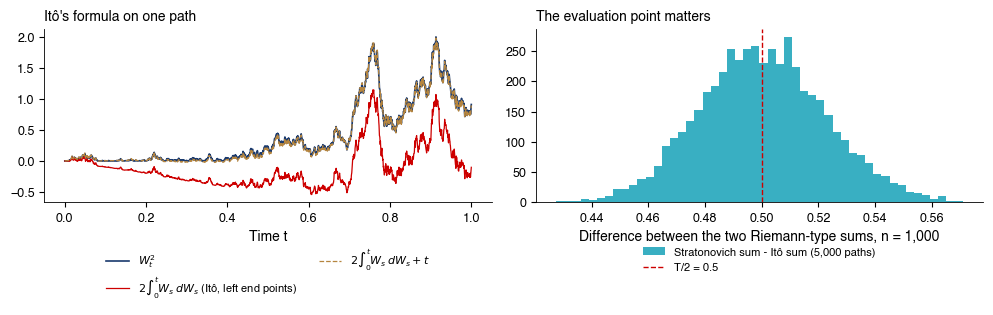

{'diff_mean': 0.5002121028100983,
 'diff_sd': 0.022289797697977353,
 'ito_err_mean': -0.0002121028100983366,
 'ito_err_sd': 0.022289797697977357,
 'ito_mean': 0.006822227653607417,
 'ito_var': 0.5201477247330386}

In [8]:
def fig_ito():
    """W_t^2 = 2 int W dW + t pe o traiectorie; diferenta Stratonovich - Ito pe 5000 de traiectorii."""
    rng = np.random.default_rng(SEED + 3)
    n = 2000
    t, W = bm_paths(1, n, 1.0, rng)
    w = W[0]
    dW = np.diff(w)
    ito_path = np.concatenate([[0], np.cumsum(w[:-1] * dW)])
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    axes[0].plot(t, w ** 2, color=MainBlue, lw=1.2, label=r'$W_t^2$')
    axes[0].plot(t, 2 * ito_path, color=IDAred, lw=0.9, label=r'$2\int_0^t W_s\,dW_s$ (Itô, left end points)')
    axes[0].plot(t, 2 * ito_path + t, color=Amber, lw=0.9, ls='--', label=r'$2\int_0^t W_s\,dW_s + t$')
    axes[0].set_xlabel('Time t')
    axes[0].set_title("Itô's formula on one path", loc='left')
    _, Wm = bm_paths(5000, 1000, 1.0, rng)
    ito, strat = ito_stratonovich(Wm)
    exact = 0.5 * (Wm[:, -1] ** 2 - 1.0)
    diff = strat - ito
    axes[1].hist(diff, bins=50, color=Teal, alpha=0.85, label='Stratonovich sum - Itô sum (5,000 paths)')
    axes[1].axvline(0.5, color=IDAred, ls='--', lw=1, label='T/2 = 0.5')
    axes[1].set_xlabel('Difference between the two Riemann-type sums, n = 1,000')
    axes[1].set_title('The evaluation point matters', loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.2)
    legend_outside_bottom(axes[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_ito')
    return dict(diff_mean=float(diff.mean()), diff_sd=float(diff.std()), ito_err_mean=float(np.mean(ito - exact)),
                ito_err_sd=float(np.std(ito - exact)), ito_mean=float(ito.mean()), ito_var=float(ito.var()))


fig_ito()

## 3. Euler–Maruyama and Milstein: strong and weak errors

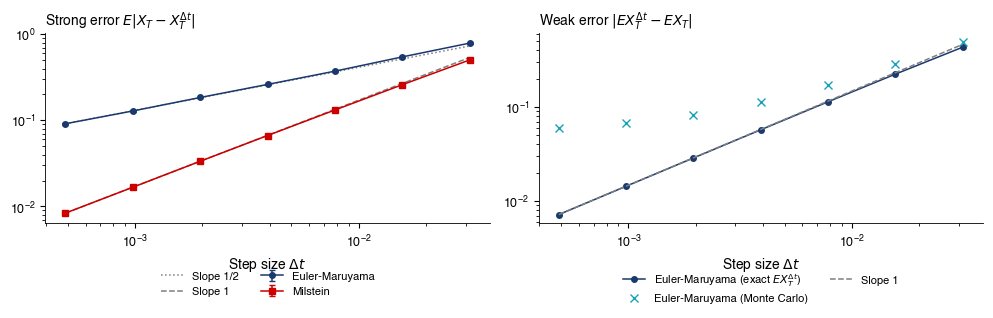

{'slope_em': {'slope': np.float64(0.5183286499303531),
  'se': np.float64(0.00363593330601912),
  'lo': np.float64(0.5089821858183152),
  'hi': np.float64(0.527675114042391),
  'intercept': np.float64(1.5447000222701894)},
 'slope_mil': {'slope': np.float64(0.98575881255588),
  'se': np.float64(0.003490571256065948),
  'lo': np.float64(0.9767860134890427),
  'hi': np.float64(0.9947316116227174),
  'intercept': np.float64(2.745813716400905)},
 'slope_weak': {'slope': np.float64(0.985127128601786),
  'se': np.float64(0.003563801316046232),
  'lo': np.float64(0.9759660856729407),
  'hi': np.float64(0.9942881715306312),
  'intercept': np.float64(2.590471619927935)}}

In [9]:
def fig_convergence():
    """Erorile tare si slabe ale schemelor Euler-Maruyama si Milstein pentru ecuatia de test a lui Higham."""
    rng = np.random.default_rng(SEED + 4)
    d = convergence_study(rng)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    axes[0].errorbar(d['dt'], d['strong_em'], yerr=1.96 * d['strong_em_se'], fmt='o-', color=MainBlue, ms=4,
                     capsize=2, label='Euler-Maruyama')
    axes[0].errorbar(d['dt'], d['strong_mil'], yerr=1.96 * d['strong_mil_se'], fmt='s-', color=IDAred, ms=4,
                     capsize=2, label='Milstein')
    x = d['dt'].values
    axes[0].plot(x, d['strong_em'].iloc[0] * (x / x[0]) ** 0.5, color=Gray, ls=':', label='Slope 1/2')
    axes[0].plot(x, d['strong_mil'].iloc[0] * (x / x[0]) ** 1.0, color=Gray, ls='--', label='Slope 1')
    axes[0].set_title(r'Strong error $E|X_T - X^{\Delta t}_T|$', loc='left')
    axes[1].plot(x, d['weak_em_exact'], 'o-', color=MainBlue, ms=4, label=r'Euler-Maruyama (exact $E X^{\Delta t}_T$)')
    axes[1].plot(x, d['weak_em_mc'], 'x', color=Teal, ms=6, label='Euler-Maruyama (Monte Carlo)')
    axes[1].plot(x, d['weak_em_exact'].iloc[0] * (x / x[0]), color=Gray, ls='--', label='Slope 1')
    axes[1].set_title(r'Weak error $|E X^{\Delta t}_T - E X_T|$', loc='left')
    for ax in axes:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'Step size $\Delta t$')
    legend_outside_bottom(axes[0], ncol=2, y=-0.2)
    legend_outside_bottom(axes[1], ncol=2, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_convergence')
    se = slope_ci(d['dt'], d['strong_em'])
    sm = slope_ci(d['dt'], d['strong_mil'])
    we = slope_ci(d['dt'], d['weak_em_exact'])
    d.to_csv(os.path.join(HERE, 'ch11_convergence.csv'), index=False)
    return dict(table=d.to_dict('list'), slope_em=se, slope_mil=sm, slope_weak=we)


res = fig_convergence()
{k: v for k, v in res.items() if k != 'table'}

## 4. Geometric Brownian motion

- Maximum likelihood estimates, the lognormal distribution after ten years, a fan chart, drift precision and tests against the data.

In [10]:
def gbm_estimates():
    """Estimatori GBM pentru S&P 500, BET, Bitcoin."""
    out = {}
    for k, r in rets.items():
        g = gbm_mle(r.values, DTS[k])
        g['start'] = str(r.index[0].date())
        g['ppy'] = periods_per_year(r)
        out[k] = g
    return out


g = gbm_estimates()
pd.DataFrame(g).T[['years', 'sigma', 'se_sigma', 'm', 'se_m', 'mu']].astype(float).round(4)

,years,sigma,se_sigma,m,se_m,mu
sp500,36.6667,0.1800,0.0013,0.0834,0.0297,0.0996
bet,26.4683,0.2220,0.0019,0.1611,0.0432,0.1858
btc,12.0110,0.6658,0.0071,0.4309,0.1921,0.6525


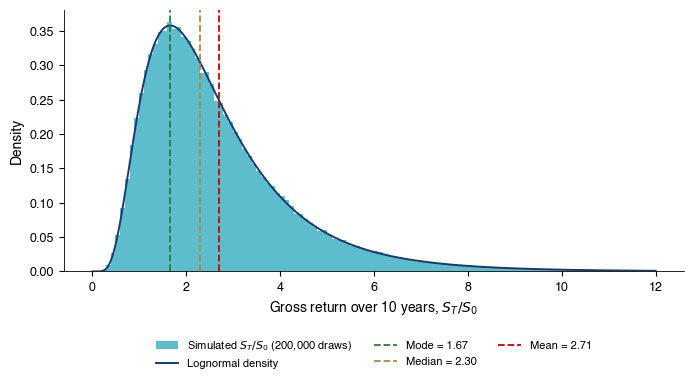

{'mode': 1.6652352207981416,
 'median': 2.302060646168358,
 'mean': 2.7066826991290522,
 'p_below1': 0.07143165159596522,
 'p_below_mean': 0.611999388632066}

In [11]:
def fig_lognormal(g):
    """Distributia lognormala a lui S_T / S_0 dupa 10 ani: modul < mediana < media."""
    mu, sigma, T = g['mu'], g['sigma'], 10.0
    m, s = (mu - 0.5 * sigma ** 2) * T, sigma * np.sqrt(T)
    rng = np.random.default_rng(SEED + 6)
    x = np.exp(m + s * rng.standard_normal(200000))
    fig, ax = plt.subplots(figsize=(8, 3.4))
    ax.hist(x, bins=np.linspace(0, 12, 121), density=True, color=Teal, alpha=0.7, label='Simulated $S_T/S_0$ (200,000 draws)')
    xx = np.linspace(0.01, 12, 600)
    ax.plot(xx, stats.lognorm.pdf(xx, s, scale=np.exp(m)), color=MainBlue, lw=1.4, label='Lognormal density')
    mode, med, mean = np.exp(m - s ** 2), np.exp(m), np.exp(m + 0.5 * s ** 2)
    for v, c, lab in [(mode, Forest, 'Mode'), (med, Amber, 'Median'), (mean, IDAred, 'Mean')]:
        ax.axvline(v, color=c, lw=1.3, ls='--', label=f'{lab} = {v:.2f}')
    ax.set_xlabel('Gross return over 10 years, $S_T / S_0$')
    ax.set_ylabel('Density')
    legend_outside_bottom(ax, ncol=3)
    save_fig('ch11_lognormal')
    return dict(mode=float(mode), median=float(med), mean=float(mean), p_below1=float(stats.norm.cdf(-m / s)),
                p_below_mean=float(stats.norm.cdf(0.5 * s)))


fig_lognormal(g['sp500'])

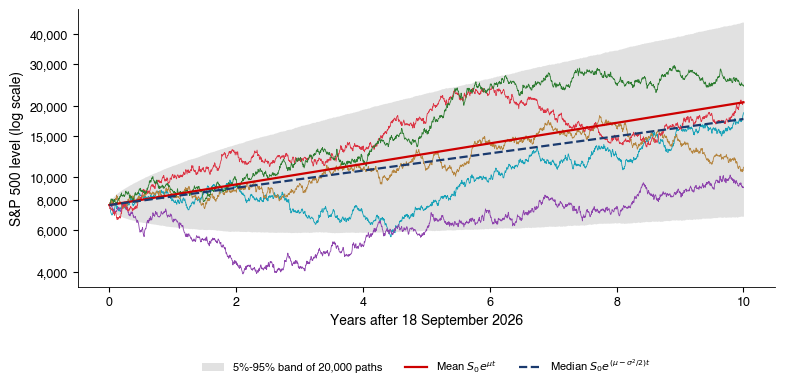

{'S0': 7650.5,
 'mean_T': 20707.475989686813,
 'median_T': 17611.914973511022,
 'q05': 6879.3112671656045,
 'q95': 45049.01984290976,
 'p_below': 0.0727,
 'p_below_exact': 0.07143165159596522,
 'mean_sim': 20772.711396189712,
 'share_below_mean': 0.61035}

In [12]:
def fig_gbm_fan(g):
    """Zece ani de traiectorii GBM pentru S&P 500 pornind de la ultima inchidere: media vs mediana."""
    rng = np.random.default_rng(SEED + 5)
    S0 = float(load_close('sp500').iloc[-1])
    T, n = 10.0, 2520
    mu, sigma = g['mu'], g['sigma']
    t, S = gbm_paths(S0, mu, sigma, T, n, 20000, rng)
    fig, ax = plt.subplots(figsize=(9, 3.6))
    q05, q95 = np.quantile(S, [0.05, 0.95], axis=0)
    ax.fill_between(t, q05, q95, color=LightGray, alpha=0.8, lw=0, label='5%-95% band of 20,000 paths')
    cols = [Teal, Purple, Amber, Crimson, Forest]
    for i in range(5):
        ax.plot(t, S[i], color=cols[i], lw=0.6)
    ax.plot(t, S0 * np.exp(mu * t), color=IDAred, lw=1.6, label=r'Mean $S_0 e^{\mu t}$')
    ax.plot(t, S0 * np.exp((mu - 0.5 * sigma ** 2) * t), color=MainBlue, lw=1.6, ls='--',
            label=r'Median $S_0 e^{(\mu - \sigma^2/2) t}$')
    ax.set_yscale('log')
    ticks = [4000, 6000, 8000, 10000, 15000, 20000, 30000, 40000]
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{v:,}' for v in ticks])
    ax.minorticks_off()
    ax.set_xlabel('Years after 18 September 2026')
    ax.set_ylabel('S&P 500 level (log scale)')
    legend_outside_bottom(ax, ncol=3)
    save_fig('ch11_gbm_fan')
    ST = S[:, -1]
    return dict(S0=S0, mean_T=float(S0 * np.exp(mu * T)), median_T=float(S0 * np.exp((mu - 0.5 * sigma ** 2) * T)),
                q05=float(np.quantile(ST, 0.05)), q95=float(np.quantile(ST, 0.95)),
                p_below=float(np.mean(ST < S0)), p_below_exact=float(stats.norm.cdf(-(mu - 0.5 * sigma ** 2) * np.sqrt(T) / sigma)),
                mean_sim=float(ST.mean()), share_below_mean=float(np.mean(ST < S0 * np.exp(mu * T))))


fig_gbm_fan(g['sp500'])

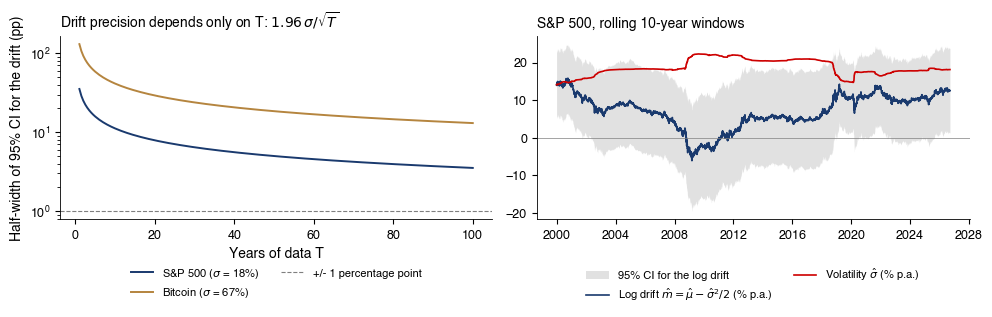

{'T_1pp_sp': 1244.0570893362246,
 'T_1pp_btc': 17027.833717210524,
 'm_min': -0.06077873316087885,
 'm_max': 0.15799126146742584,
 'm_min_date': '2009-03-05',
 'm_max_date': '2000-10-04',
 's_min': 0.1410888471319228,
 's_max': 0.22282832653206797}

In [13]:
def fig_drift_precision(g):
    """Precizia estimarii drift-ului: latimea intervalului de 95% vs durata; estimari pe ferestre de 10 ani."""
    years = np.linspace(1, 100, 200)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    for k, c in [('sp500', MainBlue), ('btc', Amber)]:
        s = g[k]['sigma']
        axes[0].plot(years, 1.96 * s / np.sqrt(years) * 100, color=c, lw=1.4,
                     label=f"{LABELS[k]} ($\\sigma$ = {100 * s:.0f}%)")
    axes[0].axhline(1.0, color=Gray, ls='--', lw=0.8, label='+/- 1 percentage point')
    axes[0].set_xlabel('Years of data T')
    axes[0].set_ylabel('Half-width of 95% CI for the drift (pp)')
    axes[0].set_yscale('log')
    axes[0].set_title(r'Drift precision depends only on T: $1.96\,\sigma/\sqrt{T}$', loc='left')
    r = rets['sp500']
    w = 2520
    m = r.rolling(w).mean() / DT
    s = r.rolling(w).std() / np.sqrt(DT)
    ci = 1.96 * s / np.sqrt(w * DT)
    axes[1].fill_between(m.index, 100 * (m - ci), 100 * (m + ci), color=LightGray, alpha=0.8, lw=0,
                         label='95% CI for the log drift')
    axes[1].plot(m.index, 100 * m, color=MainBlue, lw=1.2, label=r'Log drift $\hat m = \hat\mu - \hat\sigma^2/2$ (% p.a.)')
    axes[1].plot(s.index, 100 * s, color=IDAred, lw=1.2, label=r'Volatility $\hat\sigma$ (% p.a.)')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_title('S&P 500, rolling 10-year windows', loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.2)
    legend_outside_bottom(axes[1], ncol=2, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_drift_precision')
    mm = m.dropna()
    ss = s.dropna()
    return dict(T_1pp_sp=float((1.96 * g['sp500']['sigma'] / 0.01) ** 2), T_1pp_btc=float((1.96 * g['btc']['sigma'] / 0.01) ** 2),
                m_min=float(mm.min()), m_max=float(mm.max()), m_min_date=str(mm.idxmin().date()), m_max_date=str(mm.idxmax().date()),
                s_min=float(ss.min()), s_max=float(ss.max()))


fig_drift_precision(g)

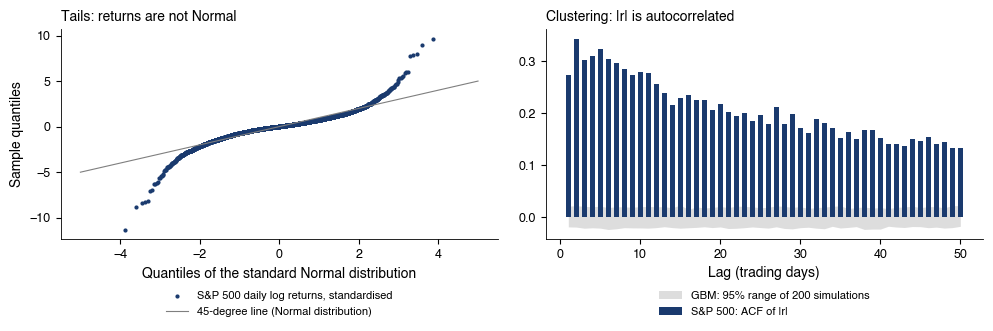

{'exkurt': 10.872824529252387,
 'skew': -0.3635937697190206,
 'acf1': 0.27457690681032093,
 'acf50': 0.13305439582899495,
 'band_hi': 0.02376132993418119,
 'n_out': 62,
 'n_out_exp': 0.5852845490760551,
 'jb': 45717.63926014909,
 'zmin': -11.289862929729601}

In [14]:
def fig_gbm_vs_data(g):
    """S&P 500: graficul QQ fata de distributia Normala si autocorelatia lui |r| fata de GBM simulat."""
    r = rets['sp500'].values
    z = (r - r.mean()) / r.std()
    n = len(z)
    q = stats.norm.ppf((np.arange(1, n + 1) - 0.5) / n)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].scatter(q, np.sort(z), s=4, color=MainBlue, label='S&P 500 daily log returns, standardised')
    axes[0].plot([-5, 5], [-5, 5], color=Gray, lw=0.8, label='45-degree line (Normal distribution)')
    axes[0].set_xlabel('Quantiles of the standard Normal distribution')
    axes[0].set_ylabel('Sample quantiles')
    axes[0].set_title('Tails: returns are not Normal', loc='left')
    lags = np.arange(1, 51)
    rng = np.random.default_rng(SEED + 7)
    sims = np.array([acf(np.abs(gbm_simulate_returns(g['m'], g['sigma'], n, DT, rng)), lags) for _ in range(200)])
    lo, hi = np.quantile(sims, [0.025, 0.975], axis=0)
    a = acf(np.abs(r), lags)
    axes[1].fill_between(lags, lo, hi, color=LightGray, alpha=0.9, lw=0, label='GBM: 95% range of 200 simulations')
    axes[1].bar(lags, a, color=MainBlue, width=0.7, label='S&P 500: ACF of |r|')
    axes[1].set_xlabel('Lag (trading days)')
    axes[1].set_title('Clustering: |r| is autocorrelated', loc='left')
    legend_outside_bottom(axes[0], ncol=1, y=-0.2)
    legend_outside_bottom(axes[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_gbm_vs_data')
    s = stylised(r)
    jb = stats.jarque_bera(r)
    return dict(exkurt=s['exkurt'], skew=s['skew'], acf1=float(a[0]), acf50=float(a[-1]), band_hi=float(hi.max()),
                n_out=int(np.sum(np.abs(z) > 4)), n_out_exp=float(n * 2 * stats.norm.sf(4)), jb=float(jb.statistic),
                zmin=float(z.min()))


fig_gbm_vs_data(g['sp500'])

## 5. Mean reversion: Ornstein–Uhlenbeck, Vasicek, the VIX

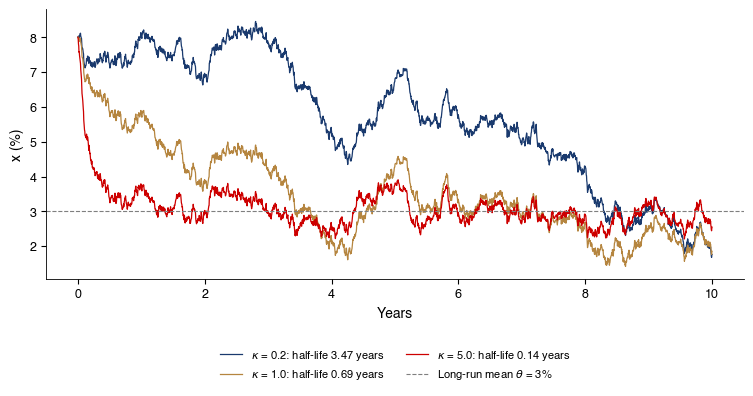

{'0.2': {'half_life': np.float64(3.465735902799726),
  'stat_sd': np.float64(0.015811388300841896)},
 '1.0': {'half_life': np.float64(0.6931471805599453),
  'stat_sd': np.float64(0.0070710678118654745)},
 '5.0': {'half_life': np.float64(0.13862943611198905),
  'stat_sd': np.float64(0.0031622776601683794)}}

In [15]:
def fig_ou_paths():
    """Trei procese OU cu aceleasi socuri si viteze de revenire diferite."""
    rng = np.random.default_rng(SEED + 8)
    dt, n = 1 / 252, 252 * 10
    z = rng.standard_normal(n)
    theta, sigma, x0 = 0.03, 0.01, 0.08
    fig, ax = plt.subplots(figsize=(9, 3.5))
    t = np.arange(n + 1) * dt
    out = {}
    for kappa, c in [(0.2, MainBlue), (1.0, Amber), (5.0, IDAred)]:
        x = ou_exact_path(x0, kappa, theta, sigma, dt, n, rng, z=z)
        ax.plot(t, 100 * x, color=c, lw=0.9, label=f'$\\kappa$ = {kappa}: half-life {np.log(2) / kappa:.2f} years')
        out[str(kappa)] = dict(half_life=np.log(2) / kappa, stat_sd=sigma / np.sqrt(2 * kappa))
    ax.axhline(100 * theta, color=Gray, ls='--', lw=0.8, label=r'Long-run mean $\theta$ = 3%')
    ax.set_xlabel('Years')
    ax.set_ylabel('x (%)')
    legend_outside_bottom(ax, ncol=2)
    save_fig('ch11_ou_paths')
    return out


fig_ou_paths()

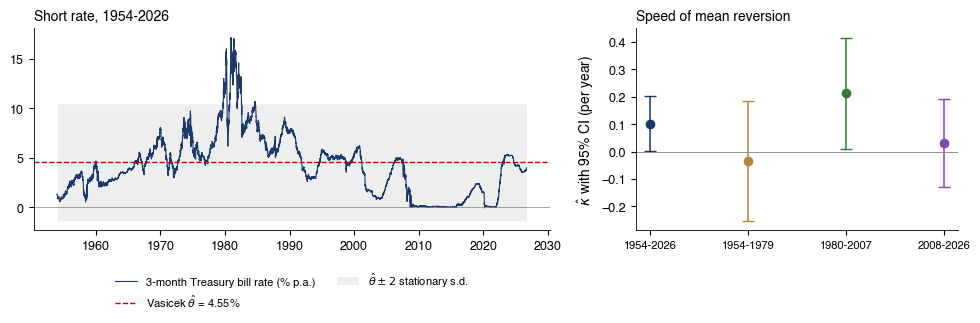

,1954-2026,1954-1979,1980-2007,2008-2026
n,18169.0000,6489.0000,6997.0000,4681.0000
a,0.0000,0.0000,0.0000,0.0000
b,0.9996,1.0001,0.9992,0.9999
kappa,0.1014,-0.0340,0.2129,0.0321
se_kappa,0.0514,0.1118,0.1037,0.0822
theta,0.0455,-0.0775,0.0429,0.0276
se_theta,0.0155,0.4073,0.0169,0.0569
sigma,0.0133,0.0123,0.0171,0.0062
half_life,6.8325,-20.3581,3.2554,21.5655
se_half_life,3.4645,66.8261,1.5858,55.1553


In [16]:
def fig_vasicek():
    """Randamentul titlurilor de stat pe 3 luni (FRED, DTB3): estimari Vasicek pe intreaga perioada si pe subperioade."""
    tb = read_fred('DTB3') / 100
    full = ou_mle(tb.values, DT)
    subs = [('1954', '1979'), ('1980', '2007'), ('2008', '2026')]
    res = {'1954-2026': full}
    for a, b in subs:
        res[f'{a}-{b}'] = ou_mle(tb.loc[a:b].values, DT)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={'width_ratios': [1.6, 1]})
    axes[0].plot(tb.index, 100 * tb, color=MainBlue, lw=0.8, label='3-month Treasury bill rate (% p.a.)')
    axes[0].axhline(100 * full['theta'], color=IDAred, ls='--', lw=1, label=rf"Vasicek $\hat\theta$ = {100 * full['theta']:.2f}%")
    axes[0].fill_between(tb.index, 100 * (full['theta'] - 2 * full['stat_sd']), 100 * (full['theta'] + 2 * full['stat_sd']),
                         color=LightGray, alpha=0.45, lw=0, label=r'$\hat\theta \pm 2$ stationary s.d.')
    axes[0].axhline(0, color=Gray, lw=0.5)
    axes[0].set_title('Short rate, 1954-2026', loc='left')
    labs = list(res)
    k = np.array([res[l]['kappa'] for l in labs])
    se = np.array([res[l]['se_kappa'] for l in labs])
    cols = [MainBlue, Amber, Forest, Purple]
    for i, (l, c) in enumerate(zip(labs, cols)):
        axes[1].errorbar(i, k[i], yerr=1.96 * se[i], fmt='o', color=c, capsize=4, ms=6)
    axes[1].axhline(0, color=Gray, lw=0.6)
    axes[1].set_xticks(range(len(labs)))
    axes[1].set_xticklabels(labs, fontsize=8)
    axes[1].set_ylabel(r'$\hat\kappa$ with 95% CI (per year)')
    axes[1].set_title('Speed of mean reversion', loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.15)
    plt.tight_layout()
    save_fig('ch11_vasicek')
    out = {k2: {c: float(v) for c, v in d.items()} for k2, d in res.items()}
    out['last'] = float(tb.iloc[-1])
    out['min'] = float(tb.min())
    out['min_date'] = str(tb.idxmin().date())
    out['max'] = float(tb.max())
    out['max_date'] = str(tb.idxmax().date())
    out['share_zero'] = float(np.mean(tb < 0.0005))
    out['p_neg'] = float(stats.norm.cdf(-full['theta'] / full['stat_sd']))
    return out


vs = fig_vasicek()
pd.DataFrame({k: v for k, v in vs.items() if isinstance(v, dict)}).round(4)

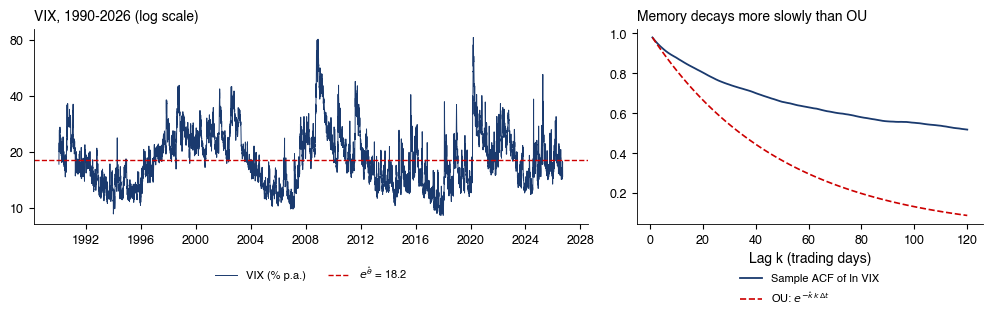

{'n': 9283.0,
 'a': 0.058132189294587584,
 'b': 0.9799801296266062,
 'kappa': 5.096191820402664,
 'se_kappa': 0.5316272238809061,
 'theta': 2.903724560167214,
 'se_theta': 0.03507277117441669,
 'sigma': 1.0848035420536837,
 'half_life': 0.13601277286795257,
 'se_half_life': 0.014188652115222106,
 'stat_sd': 0.33979204991697554,
 'hl_days': 34.27521876272405,
 'level': 18.24196228304848,
 'acf60': 0.6299817971728271,
 'ou60': 0.29719136981794597,
 'vix_last': 14.81,
 'vix_max': 82.69,
 'vix_max_date': '2020-03-16'}

In [17]:
def fig_vix_ou():
    """Logaritmul VIX ca proces OU: nivelul pe termen lung, timpul de injumatatire, autocorelatia."""
    vix = load_vix()
    x = np.log(vix)
    f = ou_mle(x.values, DT)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={'width_ratios': [1.6, 1]})
    axes[0].plot(vix.index, vix, color=MainBlue, lw=0.7, label='VIX (% p.a.)')
    axes[0].axhline(np.exp(f['theta']), color=IDAred, ls='--', lw=1, label=rf"$e^{{\hat\theta}}$ = {np.exp(f['theta']):.1f}")
    axes[0].set_yscale('log')
    axes[0].set_yticks([10, 20, 40, 80])
    axes[0].set_yticklabels(['10', '20', '40', '80'])
    axes[0].minorticks_off()
    axes[0].set_title('VIX, 1990-2026 (log scale)', loc='left')
    lags = np.arange(1, 121)
    a = acf(x.values, lags)
    axes[1].plot(lags, a, color=MainBlue, lw=1.3, label='Sample ACF of ln VIX')
    axes[1].plot(lags, f['b'] ** lags, color=IDAred, ls='--', lw=1.2, label=r'OU: $e^{-\hat\kappa\,k\,\Delta t}$')
    axes[1].set_xlabel('Lag k (trading days)')
    axes[1].set_title('Memory decays more slowly than OU', loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.15)
    legend_outside_bottom(axes[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_vix_ou')
    out = {c: float(v) for c, v in f.items()}
    out.update(hl_days=float(f['half_life'] * 252), level=float(np.exp(f['theta'])), acf60=float(a[59]), ou60=float(f['b'] ** 60),
               vix_last=float(vix.iloc[-1]), vix_max=float(vix.max()), vix_max_date=str(vix.idxmax().date()))
    return out


fig_vix_ou()

## 6. Jumps: Merton and the Lee–Mykland test

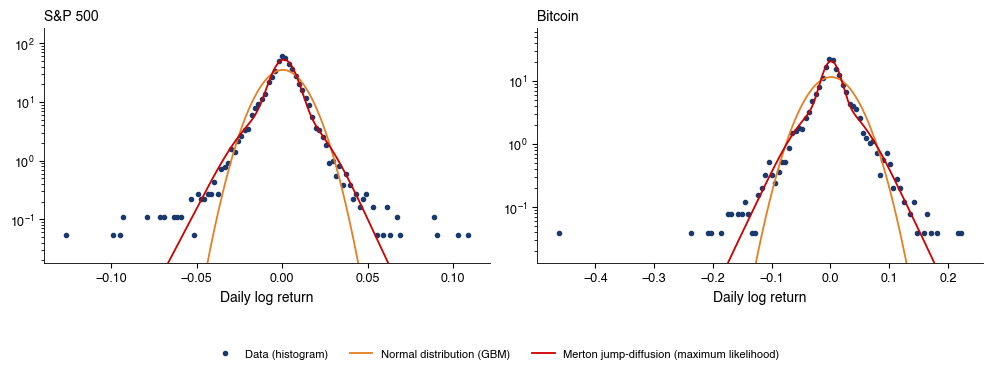

,sp500,btc,bet
sigma,0.0946,0.2458,0.1126
lam,101.4878,239.2066,78.5865
mu_j,-0.0016,-0.0000,-0.0009
s_j,0.0145,0.0385,0.0207
jump_share,0.7059,0.8546,0.7274
lr,2396.7246,1357.4131,2325.8009
data_exkurt,10.8728,11.9577,11.0629


In [18]:
def merton_estimates():
    out = {}
    for k in ['sp500', 'btc', 'bet']:
        r = rets[k].values
        mf = merton_mle(r, DTS[k])
        mo = merton_moments(DTS[k], mf['sigma'], mf['lam'], mf['mu_j'], mf['s_j'], mf['m'])
        ll0 = float(stats.norm.logpdf(r, r.mean(), r.std()).sum())
        tot = mf['sigma'] ** 2 + mf['lam'] * (mf['mu_j'] ** 2 + mf['s_j'] ** 2)
        out[k] = dict(mf, moments=mo, ll_gbm=ll0, lr=2 * (mf['loglik'] - ll0), jump_share=mf['lam'] * (mf['mu_j'] ** 2 + mf['s_j'] ** 2) / tot,
                      data_exkurt=float(stats.kurtosis(r)), data_skew=float(stats.skew(r)))
    return out


def fig_merton_density(me):
    """Densitatea randamentelor (scara log): date, distributia Normala, Merton."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, k in zip(axes, ['sp500', 'btc']):
        r = rets[k].values
        dt = DTS[k]
        mf = me[k]
        h, e = np.histogram(r, bins=120, density=True)
        c = 0.5 * (e[1:] + e[:-1])
        ok = h > 0
        ax.plot(c[ok], h[ok], 'o', ms=3, color=MainBlue, label='Data (histogram)')
        xx = np.linspace(e[0], e[-1], 800)
        ax.plot(xx, stats.norm.pdf(xx, r.mean(), r.std()), color=Orange, lw=1.3, label='Normal distribution (GBM)')
        ax.plot(xx, np.exp(merton_logpdf(xx, dt, mf['m'], mf['sigma'], mf['lam'], mf['mu_j'], mf['s_j'])), color=IDAred,
                lw=1.3, label='Merton jump-diffusion (maximum likelihood)')
        ax.set_yscale('log')
        ax.set_ylim(h[ok].min() / 3, h.max() * 3)
        ax.set_xlabel('Daily log return')
        ax.set_title(LABELS[k], loc='left')
    fig_legend_bottom(plt.gcf(), ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch11_merton_density')


me = merton_estimates()
fig_merton_density(me)
pd.DataFrame({k: {c: v[c] for c in ['sigma', 'lam', 'mu_j', 's_j', 'jump_share', 'lr', 'data_exkurt']} for k, v in me.items()}).round(4)

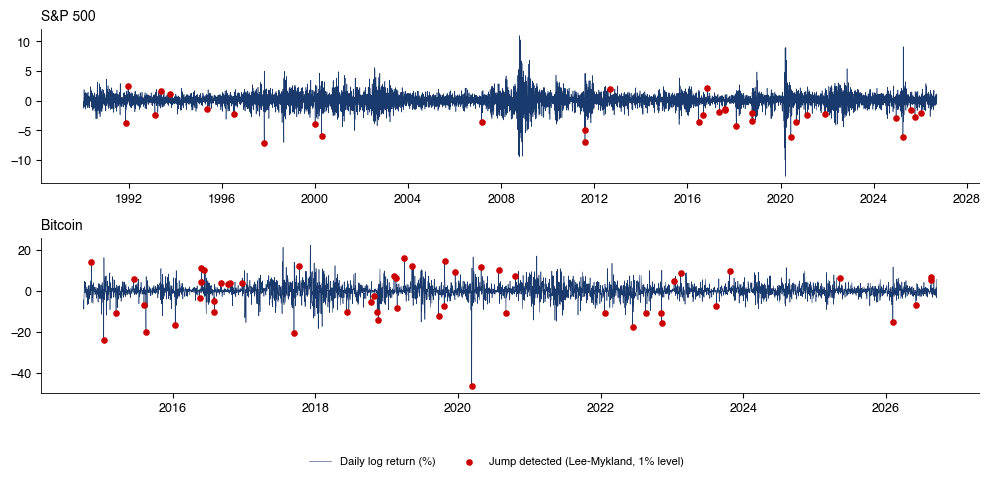

{'sp500': {'n': 9225,
  'n_jumps': 32,
  'per_year': 0.8731510533393098,
  'crit': 4.600149226776579,
  'share_neg': 0.84375,
  'top10_detected': 0,
  'largest': 0.07112744612876032,
  'smallest': 0.011504780463758912,
  'smallest_date': '1993-10-14'},
 'btc': {'n': 4369,
  'n_jumps': 52,
  'per_year': 4.348214285714286,
  'crit': 4.600149226776579,
  'share_neg': 0.5192307692307693,
  'top10_detected': 5,
  'largest': 0.46473020666317133,
  'smallest': 0.023990503887182157,
  'smallest_date': '2018-10-29'}}

In [19]:
def fig_jumps():
    """Salturi detectate cu testul Lee-Mykland (alpha = 1%) pentru S&P 500 si Bitcoin."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 4.6), sharex=False)
    out = {}
    for ax, k in zip(axes, ['sp500', 'btc']):
        d, crit = lee_mykland(rets[k], K=16, alpha=0.01)
        ax.plot(d.index, 100 * d['r'], color=MainBlue, lw=0.4, label='Daily log return (%)')
        j = d[d['jump']]
        ax.scatter(j.index, 100 * j['r'], s=14, color=IDAred, zorder=3, label='Jump detected (Lee-Mykland, 1% level)')
        ax.set_title(LABELS[k], loc='left')
        years = (d.index[-1] - d.index[0]).days / 365.25
        big = d['r'].abs().sort_values(ascending=False).head(10)
        out[k] = dict(n=int(len(d)), n_jumps=int(d['jump'].sum()), per_year=float(d['jump'].sum() / years), crit=float(crit),
                      share_neg=float((j['r'] < 0).mean()), top10_detected=int(d.loc[big.index, 'jump'].sum()),
                      largest=float(j['r'].abs().max()), smallest=float(j['r'].abs().min()),
                      smallest_date=str(j['r'].abs().idxmin().date()),
                      dates=[str(x.date()) for x in j.index])
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save_fig('ch11_jumps')
    return out


jp = fig_jumps()
{k: {c: v[c] for c in v if c != 'dates'} for k, v in jp.items()}

## 7. Stochastic volatility: Heston

- Parameters from the VIX; for real-world paths the long-run variance is set to the realised variance.

In [20]:
def heston_estimates():
    hp = heston_from_vix(load_vix(), rets['sp500'], DT)
    return hp


hp = heston_estimates()
hp['theta_p'] = hp['real_var']
hp

{'kappa': np.float64(4.133303412874438),
 'theta': np.float64(0.0436758916912511),
 'xi': np.float64(0.5577374994558045),
 'rho': np.float64(-0.6942659717991324),
 'v0': 0.021933610000000003,
 'n': 9238,
 'feller': np.float64(1.1606716378866013),
 'mean_vix': 19.436115380452428,
 'real_var': 0.03238868212738509,
 'theta_p': 0.03238868212738509}

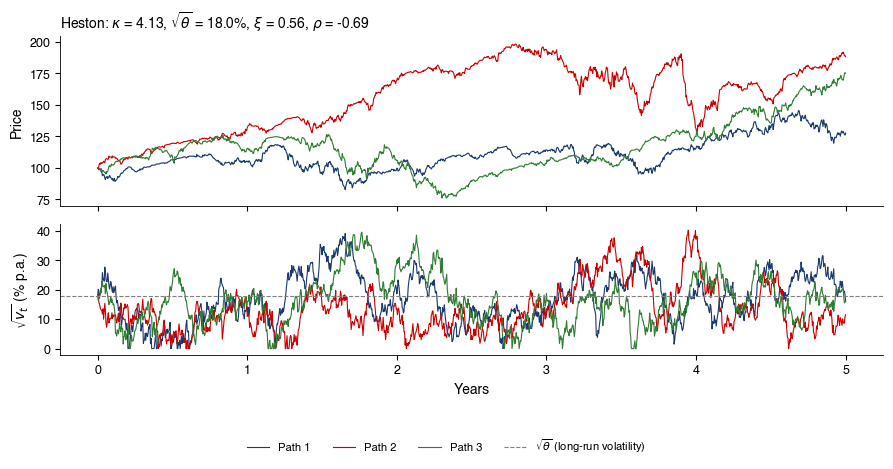

{'corr_sim': -0.6919560579625172}

In [21]:
def fig_heston_paths(hp, g):
    """Trei traiectorii Heston cu parametrii estimati din VIX (media pe termen lung = varianta realizata)."""
    rng = np.random.default_rng(SEED + 9)
    t, S, V = heston_paths(100.0, hp['theta_p'], g['mu'], hp['kappa'], hp['theta_p'], hp['xi'], hp['rho'], 5.0, 1260, 3, rng)
    fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
    for i, c in enumerate([MainBlue, IDAred, Forest]):
        axes[0].plot(t, S[:, i], color=c, lw=0.8, label=f'Path {i + 1}')
        axes[1].plot(t, 100 * np.sqrt(V[:, i]), color=c, lw=0.8)
    axes[1].axhline(100 * np.sqrt(hp['theta_p']), color=Gray, ls='--', lw=0.8, label=r'$\sqrt{\theta}$ (long-run volatility)')
    axes[0].set_ylabel('Price')
    axes[1].set_ylabel(r'$\sqrt{v_t}$ (% p.a.)')
    axes[1].set_xlabel('Years')
    axes[0].set_title(rf"Heston: $\kappa$ = {hp['kappa']:.2f}, $\sqrt{{\theta}}$ = {100 * np.sqrt(hp['theta_p']):.1f}%, "
                      rf"$\xi$ = {hp['xi']:.2f}, $\rho$ = {hp['rho']:.2f}", loc='left')
    fig_legend_bottom(fig, ncol=4, y=0.02)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save_fig('ch11_heston_paths')
    lr = np.diff(np.log(S), axis=0)
    dv = np.diff(V, axis=0)
    return dict(corr_sim=float(np.corrcoef(lr.ravel(), dv.ravel())[0, 1]))


fig_heston_paths(hp, g['sp500'])

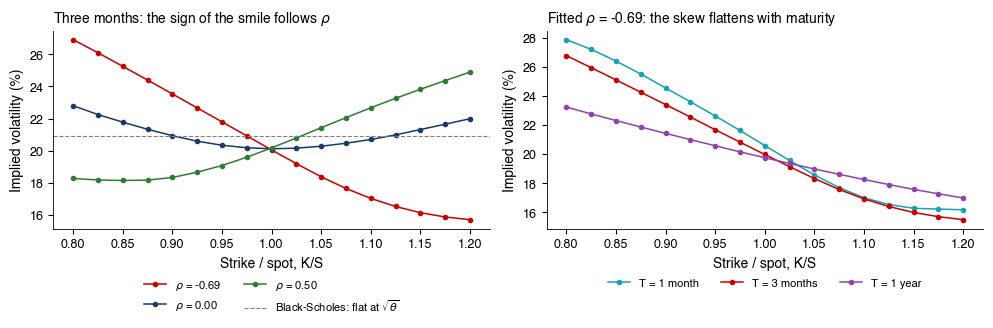

In [22]:
def fig_heston_smile(hp):
    """Volatilitatea implicita Black-Scholes a preturilor Heston: efectul lui rho si al scadentei."""
    rng = np.random.default_rng(SEED + 10)
    K = np.linspace(0.80, 1.20, 17)
    base = dict(kappa=hp['kappa'], theta=hp['theta'], xi=hp['xi'], rho=hp['rho'], v0=hp['theta'])
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    out = {'K': K}
    for rho, c in [(hp['rho'], IDAred), (0.0, MainBlue), (0.5, Forest)]:
        p = dict(base, rho=rho)
        iv = heston_smile(p, 0.25, K, rng, n_paths=100000, n_steps=63)
        axes[0].plot(K, 100 * iv, 'o-', ms=3, color=c, label=rf'$\rho$ = {rho:.2f}')
        out[f'rho_{rho:.2f}'] = iv
    axes[0].axhline(100 * np.sqrt(hp['theta']), color=Gray, ls='--', lw=0.8, label=r'Black-Scholes: flat at $\sqrt{\theta}$')
    axes[0].set_title('Three months: the sign of the smile follows $\\rho$', loc='left')
    for T, c in [(1 / 12, Teal), (0.25, IDAred), (1.0, Purple)]:
        iv = heston_smile(base, T, K, rng, n_paths=100000, n_steps=max(int(252 * T), 21))
        axes[1].plot(K, 100 * iv, 'o-', ms=3, color=c, label=f'T = {"1 month" if T < 0.1 else ("3 months" if T < 0.5 else "1 year")}')
        out[f'T_{T:.3f}'] = iv
    axes[1].set_title(rf'Fitted $\rho$ = {hp["rho"]:.2f}: the skew flattens with maturity', loc='left')
    for ax in axes:
        ax.set_xlabel('Strike / spot, K/S')
        ax.set_ylabel('Implied volatility (%)')
    legend_outside_bottom(axes[0], ncol=2, y=-0.2)
    legend_outside_bottom(axes[1], ncol=3, y=-0.2)
    plt.tight_layout()
    save_fig('ch11_heston_smile')
    return out


sm = fig_heston_smile(hp)

## 7b. Estimating diffusions: exact CIR, Euler, CKLS and nonparametric estimates

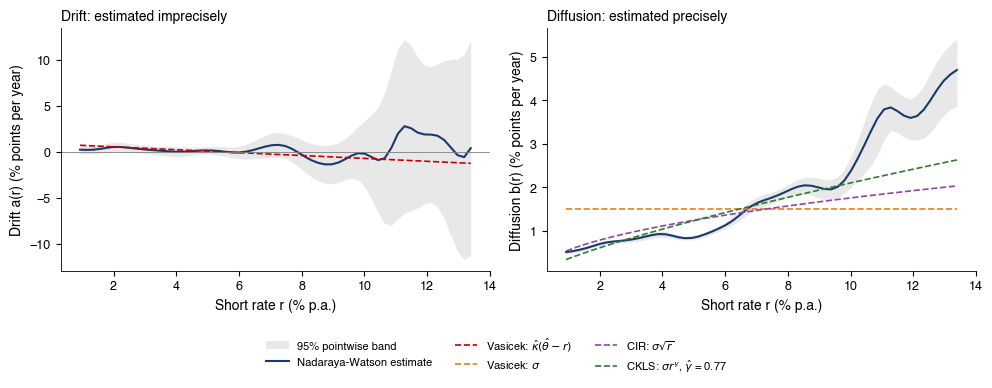

,vasicek_exact,vasicek_euler,cir_euler,cir_exact,ckls
kappa,0.1577,0.1577,0.0931,0.1125,0.0800
theta,0.0539,0.0539,0.0555,0.0548,0.0584
sigma,0.0150,0.0150,0.0555,0.0556,0.1236
gamma,0.0000,0.0000,0.5000,0.5000,0.7699
se_kappa,0.0735,0.0734,0.0603,0.0604,0.0566
se_theta,0.0130,0.0130,0.0200,0.0164,NaN
se_sigma,0.0001,0.0001,0.0003,0.0003,NaN
loglik,74815.6762,74815.6762,78209.3210,78198.7253,78778.9916
se_gamma,NaN,NaN,NaN,NaN,0.0077
se_gamma_rob,NaN,NaN,NaN,NaN,0.0197


In [23]:
def diffusion_fits():
    """Vasicek, CIR (exact si Euler) si CKLS pe randamentul titlurilor de stat pe 3 luni (FRED, DTB3), 1954-2007:
    date zilnice si sfarsit de luna. Perioada 2008-2026 este exclusa: CIR are suport r > 0, iar ratele au atins 0."""
    tb = read_fred('DTB3') / 100
    s = tb.loc['1954':'2007']
    out = {'daily': short_rate_fits(s.values, DT), 'monthly': short_rate_fits(s.resample('ME').last().values, 1 / 12)}
    out['min_rate'] = float(s.min())
    out['share_zero_post2008'] = float(np.mean(tb.loc['2008':] < 0.0005))
    return out


def fig_np_diffusion(fits):
    """Driftul si difuzia neparametrice (Nadaraya-Watson) ale ratei pe 3 luni, 1954-2007, fata de Vasicek, CIR, CKLS."""
    tb = (read_fred('DTB3') / 100).loc['1954':'2007']
    x = tb.values
    grid = np.linspace(np.quantile(x, 0.02), np.quantile(x, 0.98), 60)
    nw = nw_drift_diffusion(x, DT, grid)
    F = fits['daily']
    lo_a, hi_a = nw['drift'] - 1.96 * nw['drift_se'], nw['drift'] + 1.96 * nw['drift_se']
    b = np.sqrt(np.maximum(nw['diff2'], 0))
    lo_b = np.sqrt(np.maximum(nw['diff2'] - 1.96 * nw['diff2_se'], 0))
    hi_b = np.sqrt(nw['diff2'] + 1.96 * nw['diff2_se'])
    vas = F['vasicek_exact']
    par_a = vas['kappa'] * (vas['theta'] - grid)
    par_b = {'Vasicek': np.full_like(grid, F['vasicek_euler']['sigma']),
             'CIR': F['cir_euler']['sigma'] * np.sqrt(grid),
             'CKLS': F['ckls']['sigma'] * grid ** F['ckls']['gamma']}
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    g100 = 100 * grid
    axes[0].fill_between(g100, 100 * lo_a, 100 * hi_a, color=LightGray, alpha=0.6, lw=0, label='95% pointwise band')
    axes[0].plot(g100, 100 * nw['drift'], color=MainBlue, lw=1.5, label='Nadaraya-Watson estimate')
    axes[0].plot(g100, 100 * par_a, color=IDAred, ls='--', lw=1.2, label=r'Vasicek: $\hat\kappa(\hat\theta - r)$')
    axes[0].axhline(0, color=Gray, lw=0.6)
    axes[0].set_xlabel('Short rate r (% p.a.)')
    axes[0].set_ylabel('Drift a(r) (% points per year)')
    axes[0].set_title('Drift: estimated imprecisely', loc='left')
    axes[1].fill_between(g100, 100 * lo_b, 100 * hi_b, color=LightGray, alpha=0.6, lw=0)
    axes[1].plot(g100, 100 * b, color=MainBlue, lw=1.5)
    cols = {'Vasicek': Orange, 'CIR': Purple, 'CKLS': Forest}
    for k, v in par_b.items():
        lab = {'Vasicek': r'Vasicek: $\sigma$', 'CIR': r'CIR: $\sigma\sqrt{r}$',
               'CKLS': rf"CKLS: $\sigma r^{{\gamma}}$, $\hat\gamma$ = {F['ckls']['gamma']:.2f}"}[k]
        axes[1].plot(g100, 100 * v, color=cols[k], lw=1.2, ls='--', label=lab)
    axes[1].set_xlabel('Short rate r (% p.a.)')
    axes[1].set_ylabel('Diffusion b(r) (% points per year)')
    axes[1].set_title('Diffusion: estimated precisely', loc='left')
    fig_legend_bottom(fig, ncol=3, y=0.03)
    plt.tight_layout(rect=(0, 0.03, 1, 1))
    save_fig('ch11_np_diffusion')
    inside = {k: float(np.mean((v >= lo_b) & (v <= hi_b))) for k, v in par_b.items()}
    rel = nw['diff2_se'] / nw['diff2']
    out = dict(h=float(nw['h']), inside=inside, zero_in_drift_band=float(np.mean((lo_a <= 0) & (hi_a >= 0))),
               vas_in_drift_band=float(np.mean((lo_a <= par_a) & (hi_a >= par_a))),
               drift_se_med=float(np.median(nw['drift_se'])), diff_relse_med=float(np.median(rel)),
               drift_ratio=float(np.median(nw['drift_se'] / np.abs(np.sqrt(nw['diff2'])))),
               b_lo=float(b[0]), b_hi=float(b[-1]), r_lo=float(grid[0]), r_hi=float(grid[-1]),
               slope=float(np.polyfit(np.log(grid), np.log(b), 1)[0]))
    return out


fits = diffusion_fits()
np_res = fig_np_diffusion(fits)
pd.DataFrame({k: v for k, v in fits['daily'].items() if isinstance(v, dict)}).round(4)

## 7c. Change of measure: market price of risk, the Vasicek bond, the VIX under Heston

In [24]:
def measure_change(g, vs, hp):
    """Schimbarea masurii: pretul de piata al riscului pentru S&P 500; preturile obligatiunilor Vasicek (Feynman-Kac);
    ce identifica VIX in modelul Heston (VIX^2 afin in v_t, cu parametri sub masura neutra la risc)."""
    tb = read_fred('DTB3') / 100
    sp = g['sp500']
    rbar = float(tb.loc[sp['start']:].mean())
    th = (sp['mu'] - rbar) / sp['sigma']
    out = {'rbar': rbar, 'theta_sp': th, 'se_theta_sp': 1 / np.sqrt(sp['years'])}
    F = vs['1954-2026']
    k, t, s, r0 = F['kappa'], F['theta'], F['sigma'], vs['last']
    ys = {}
    for tau in (1, 5, 10, 30):
        B = (1 - np.exp(-k * tau)) / k
        A = (t - s ** 2 / (2 * k ** 2)) * (B - tau) - s ** 2 * B ** 2 / (4 * k)
        ys[str(tau)] = float((B * r0 - A) / tau)
    out['vas_yields'] = ys
    out['vas_yinf'] = float(t - s ** 2 / (2 * k ** 2))
    dgs10 = read_fred('DGS10') / 100
    out['dgs10_last'] = float(dgs10.iloc[-1])
    out['dgs10_date'] = str(dgs10.index[-1].date())
    tau = 30 / 365
    out['vix_b'] = {str(kq): float((1 - np.exp(-kq * tau)) / (kq * tau)) for kq in (1.0, 2.5, 5.0, 10.0)}
    out['vix_xi_corr'] = {kq: float(hp['xi'] / b) for kq, b in out['vix_b'].items()}
    return out


measure_change(g, vs, hp)

{'rbar': 0.02731440548780488,
 'theta_sp': np.float64(0.4015334154790796),
 'se_theta_sp': np.float64(0.1651445647689541),
 'vas_yields': {'1': 0.040148597875418565,
  '5': 0.040601342951700516,
  '10': 0.040519824536927804,
  '30': 0.039148486486491274},
 'vas_yinf': 0.036945970379192755,
 'dgs10_last': 0.0501,
 'dgs10_date': '2026-09-18',
 'vix_b': {'1.0': 0.9600072643152168,
  '2.5': 0.903950114927175,
  '5.0': 0.8199988330494161,
  '10.0': 0.6818348427338535},
 'vix_xi_corr': {'1.0': 0.5809721657196464,
  '2.5': 0.61700030814282,
  '5.0': 0.6801686502183025,
  '10.0': 0.8179950106678708}}

## 8. Which model reproduces the S&P 500?

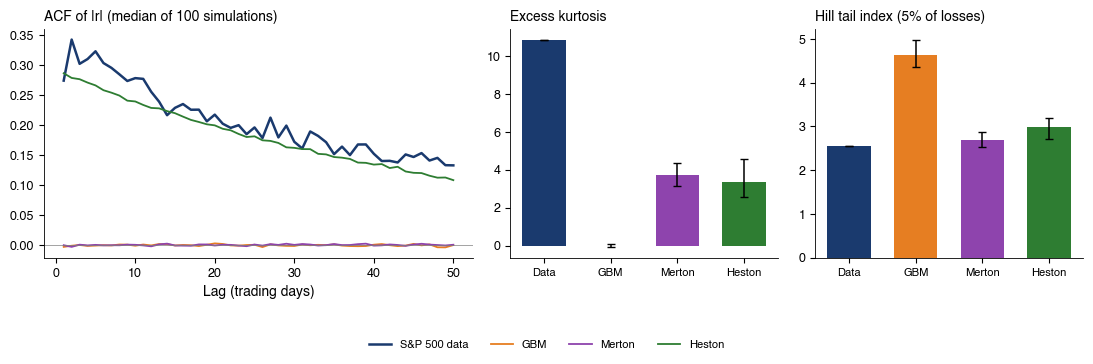

,GBM,Merton,Heston,Data
exkurt,0.004,3.718,3.344,10.873
skew,-0.000,-0.303,0.008,-0.364
hill,4.640,2.684,2.977,2.556
acf_abs1,-0.003,-0.000,0.287,0.275
acf_abs_sum20,-0.001,0.002,4.775,5.323


In [25]:
def simulate_stats(model, p, n, dt, n_sim, rng, mu=0.0):
    out = []
    for _ in range(n_sim):
        if model == 'GBM':
            x = gbm_simulate_returns(p['m'], p['sigma'], n, dt, rng)
        elif model == 'Merton':
            x = merton_simulate_returns(p['m'], p['sigma'], p['lam'], p['mu_j'], p['s_j'], n, dt, rng)
        else:
            x = heston_simulate_returns(p, n, dt, rng, mu=mu)
        out.append(stylised(x))
    return out


def fig_models_vs_data(g, me, hp):
    """ACF |r|, aplatizare si indicele de coada: S&P 500 vs GBM, Merton, Heston (100 de simulari fiecare)."""
    rng = np.random.default_rng(SEED + 11)
    r = rets['sp500'].values
    n = len(r)
    hpp = dict(hp, theta=hp['theta_p'])
    S = {'GBM': simulate_stats('GBM', g['sp500'], n, DT, 100, rng),
         'Merton': simulate_stats('Merton', me['sp500'], n, DT, 100, rng),
         'Heston': simulate_stats('Heston', hpp, n, DT, 100, rng, mu=g['sp500']['mu'])}
    d = stylised(r)
    lags = np.arange(1, 51)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), gridspec_kw={'width_ratios': [1.6, 1, 1]})
    axes[0].plot(lags, d['acf_abs'], color=MODEL_COL['Data'], lw=1.8, label='S&P 500 data')
    for m, s in S.items():
        axes[0].plot(lags, np.median([x['acf_abs'] for x in s], axis=0), color=MODEL_COL[m], lw=1.3, label=m)
    axes[0].axhline(0, color=Gray, lw=0.5)
    axes[0].set_xlabel('Lag (trading days)')
    axes[0].set_title('ACF of |r| (median of 100 simulations)', loc='left')
    summ = {}
    for ax, key, title in [(axes[1], 'exkurt', 'Excess kurtosis'), (axes[2], 'hill', 'Hill tail index (5% of losses)')]:
        names = ['Data'] + list(S)
        vals, lo, hi = [d[key]], [0], [0]
        for m in S:
            v = np.array([x[key] for x in S[m]])
            med = np.median(v)
            vals.append(med)
            lo.append(med - np.quantile(v, 0.05))
            hi.append(np.quantile(v, 0.95) - med)
        ax.bar(range(4), vals, color=[MODEL_COL[nm] for nm in names], yerr=[lo, hi], capsize=3, width=0.65)
        ax.set_xticks(range(4))
        ax.set_xticklabels(names, fontsize=8)
        ax.set_title(title, loc='left')
    fig_legend_bottom(fig, ncol=4, y=0.02)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save_fig('ch11_models_vs_data')
    for m in S:
        summ[m] = {k: dict(med=float(np.median([x[k] for x in S[m]])), lo=float(np.quantile([x[k] for x in S[m]], 0.05)),
                           hi=float(np.quantile([x[k] for x in S[m]], 0.95)),
                           p_ge=float(np.mean([x[k] >= d[k] for x in S[m]])))
                   for k in ['exkurt', 'skew', 'hill', 'acf_abs1', 'acf_abs_sum20']}
    summ['Data'] = {k: float(d[k]) for k in ['exkurt', 'skew', 'hill', 'acf_abs1', 'acf_abs_sum20']}
    return summ


cp = fig_models_vs_data(g, me, hp)
pd.DataFrame({m: {k: v['med'] if isinstance(v, dict) else v for k, v in d.items()} for m, d in cp.items()}).round(3)